In [1]:
from pathlib import Path
import os

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import mplhep as hep
from matplotlib import colors
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from functools import reduce
import inspect


from boostedhh import utils, hh_vars



In [ ]:
# automatically reloads imported files on edits
%load_ext autoreload
%autoreload 2


def print_directory_tree(base_dir, indent=""):
    for root, dirs, files in os.walk(base_dir):
        level = root.replace(base_dir, "").count(os.sep)
        indent = " " * 4 * level
        print(f"{indent}|-- {os.path.basename(root)}/")
        sub_indent = " " * 4 * (level + 1)
        for file in files:
            print(f"{sub_indent}|-- {file}")

In [3]:
MAIN_DIR = Path("../../../")

plot_dir = MAIN_DIR / "plots/TriggerStudy/24Nov9"
plot_dir.mkdir(parents=True, exist_ok=True)

samples_tag = "25Feb7NoFatJetSel_v12_private_signal"
# samples_tag = "24Nov9UpdateTriggers_v12_private_signal"
base_dir = f"/eos/uscms/store/user/rkansal/bbtautau/skimmer/{samples_tag}/2022/"
print_directory_tree(base_dir)

|-- /
|-- GluGlutoHHto2B2Tau_kl-1p00_kt-1p00_c2-0p00_LHEweights_TuneCP5_13p6TeV_powheg-pythia8/
    |-- githashes/
        |-- commithash_0.txt
        |-- commithash_1.txt
        |-- commithash_2.txt
        |-- commithash_3.txt
        |-- commithash_4.txt
        |-- commithash_5.txt
    |-- parquet/
        |-- out_0.parquet
        |-- out_1.parquet
        |-- out_2.parquet
        |-- out_3.parquet
        |-- out_4.parquet
        |-- out_5.parquet
    |-- pickles/
        |-- out_0.pkl
        |-- out_1.pkl
        |-- out_2.pkl
        |-- out_3.pkl
        |-- out_4.pkl
        |-- out_5.pkl
    |-- root/


In [4]:
df = pd.read_parquet(
    base_dir + "GluGlutoHHto2B2Tau_kl-1p00_kt-1p00_c2-0p00_LHEweights_TuneCP5_13p6TeV_powheg-pythia8/parquet/"
)    

In [5]:
df.head()

GenHiggsEta           GenHiggsPhi           GenHiggsMass        GenHiggsPt  \
            0         1           0         1            0      1          0   
0   -2.320312 -1.203125   -0.259766  1.003906        125.0  125.0      68.75   
1   -0.232910  0.634766   -1.300781  1.765625        125.0  125.0     138.00   
2   -0.146484 -0.285156   -2.015625  0.851562        125.0  125.0     225.00   
3   -0.521484  0.392578   -0.851562  2.039062        125.0  125.0     118.75   
4   -1.113281 -0.611328   -0.083496  2.937500        125.0  125.0     333.00   

           GenHiggsChildren      ... ak4JetMatchedGenJetPt             \
         1                0   1  ...                     0          1   
0   40.375                5  15  ...             70.524094  70.473900   
1  126.750               15   5  ...             65.868233  61.152817   
2  169.000               15   5  ...            111.413147  87.582359   
3  120.500                5  15  ...            121.680634  78.001244   
4  331.000               15   5  ...            255.448425  55.414589   

                               weight single_weight_genweight  \
            2             3         0                       0   
0   63.408207     37.935600  0.934380                 0.65807   
1   57.869720 -99999.000000  1.035074                 0.65807   
2  105.870567     48.408783 -1.048243                -0.65807   
3   37.800751     23.528605  0.122868                 0.65807   
4   43.649437     22.225801  0.130059                 0.65807   

  single_weight_pileup single_weight_ISRPartonShower  \
                     0                             0   
0            28.212471                     19.869631   
1            31.252803                     19.869631   
2            31.650413                     19.869631   
3             3.709844                     19.869631   
4             3.926960                     19.869631   

  single_weight_FSRPartonShower weight_noxsec  
                              0             0  
0                     19.869631      0.047026  
1                     19.869631      0.052093  
2                     19.869631     -0.052756  
3                     19.869631      0.006184  
4                     19.869631      0.006546  

[5 rows x 212 columns]

In [6]:
print(df.attrs)

{}


In [7]:
base_dir + "GluGlutoHHto2B2Tau_kl-1p00_kt-1p00_c2-0p00_LHEweights_TuneCP5_13p6TeV_powheg-pythia8/parquet/"

'/eos/uscms/store/user/rkansal/bbtautau/skimmer/25Feb7NoFatJetSel_v12_private_signal/2022/GluGlutoHHto2B2Tau_kl-1p00_kt-1p00_c2-0p00_LHEweights_TuneCP5_13p6TeV_powheg-pythia8/parquet/'

In [8]:
!ls '/eos/uscms/store/user/rkansal/bbtautau/skimmer/25Feb7NoFatJetSel_v12_private_signal/2022/GluGlutoHHto2B2Tau_kl-1p00_kt-1p00_c2-0p00_LHEweights_TuneCP5_13p6TeV_powheg-pythia8/parquet/'


out_0.parquet  out_2.parquet  out_4.parquet
out_1.parquet  out_3.parquet  out_5.parquet


In [9]:
cf = utils.get_cutflow(
    base_dir + "GluGlutoHHto2B2Tau_kl-1p00_kt-1p00_c2-0p00_LHEweights_TuneCP5_13p6TeV_powheg-pythia8/pickles",
    "2022",
    "GluGlutoHHto2B2Tau_kl-1p00_kt-1p00_c2-0p00_LHEweights_TuneCP5_13p6TeV_powheg-pythia8",
)

nEvents = len(df)

In [10]:
list(df.columns)

[('GenHiggsEta', 0),
 ('GenHiggsEta', 1),
 ('GenHiggsPhi', 0),
 ('GenHiggsPhi', 1),
 ('GenHiggsMass', 0),
 ('GenHiggsMass', 1),
 ('GenHiggsPt', 0),
 ('GenHiggsPt', 1),
 ('GenHiggsChildren', 0),
 ('GenHiggsChildren', 1),
 ('GenbbEta', 0),
 ('GenbbEta', 1),
 ('GenbbPhi', 0),
 ('GenbbPhi', 1),
 ('GenbbMass', 0),
 ('GenbbMass', 1),
 ('GenbbPt', 0),
 ('GenbbPt', 1),
 ('GenTauEta', 0),
 ('GenTauEta', 1),
 ('GenTauPhi', 0),
 ('GenTauPhi', 1),
 ('GenTauMass', 0),
 ('GenTauMass', 1),
 ('GenTauPt', 0),
 ('GenTauPt', 1),
 ('GenTauhh', 0),
 ('GenTauhmu', 0),
 ('GenTauhe', 0),
 ('run', 0),
 ('event', 0),
 ('luminosityBlock', 0),
 ('MET_pt', 0),
 ('ht', 0),
 ('nJets', 0),
 ('nFatJets', 0),
 ('nPU', 0),
 ('nPV', 0),
 ('HLT_AK8PFJet425_SoftDropMass40', 0),
 ('HLT_AK8PFJet250_SoftDropMass40_PFAK8ParticleNetBB0p35', 0),
 ('HLT_AK8PFJet230_SoftDropMass40_PFAK8ParticleNetTauTau0p30', 0),
 ('HLT_QuadPFJet70_50_40_35_PFBTagParticleNet_2BTagSum0p65', 0),
 ('HLT_LooseDeepTauPFTauHPS180_L2NN_eta2p1', 0),
 ('HL

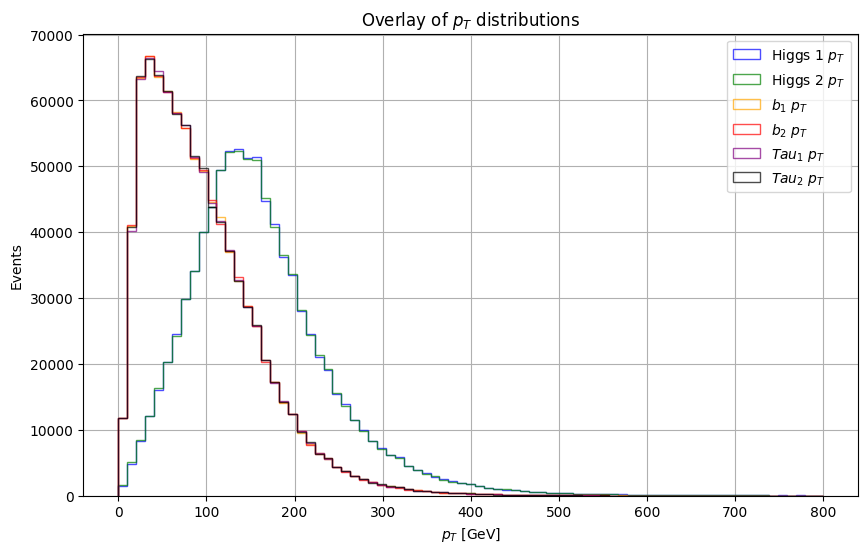

In [11]:
higgs1_pt = df[("GenHiggsPt", 0)]
higgs2_pt = df[("GenHiggsPt", 1)]
b1_pt = df[("GenbbPt", 0)]
b2_pt = df[("GenbbPt", 1)]

Tau1_pt = df[("GenTauPt", 0)]
Tau2_pt = df[("GenTauPt", 1)]

bins = np.linspace(0, 800, 80)

plt.figure(figsize=(10, 6))
plt.hist(higgs1_pt, bins=bins, alpha=0.7, label="Higgs 1 $p_T$", histtype="step", color="blue")
plt.hist(higgs2_pt, bins=bins, alpha=0.7, label="Higgs 2 $p_T$", histtype="step", color="green")

plt.hist(b1_pt, bins=bins, alpha=0.7, label="$b_1$ $p_T$", histtype="step", color="orange")
plt.hist(b2_pt, bins=bins, alpha=0.7, label="$b_2$ $p_T$", histtype="step", color="red")

plt.hist(Tau1_pt, bins=bins, alpha=0.7, label="$Tau_1$ $p_T$", histtype="step", color="purple")
plt.hist(Tau2_pt, bins=bins, alpha=0.7, label="$Tau_2$ $p_T$", histtype="step", color="black")

plt.xlabel("$p_T$ [GeV]")
plt.ylabel("Events")
plt.title("Overlay of $p_T$ distributions")
plt.legend()
plt.grid(True)
plt.show()

<Figure size 800x600 with 0 Axes>

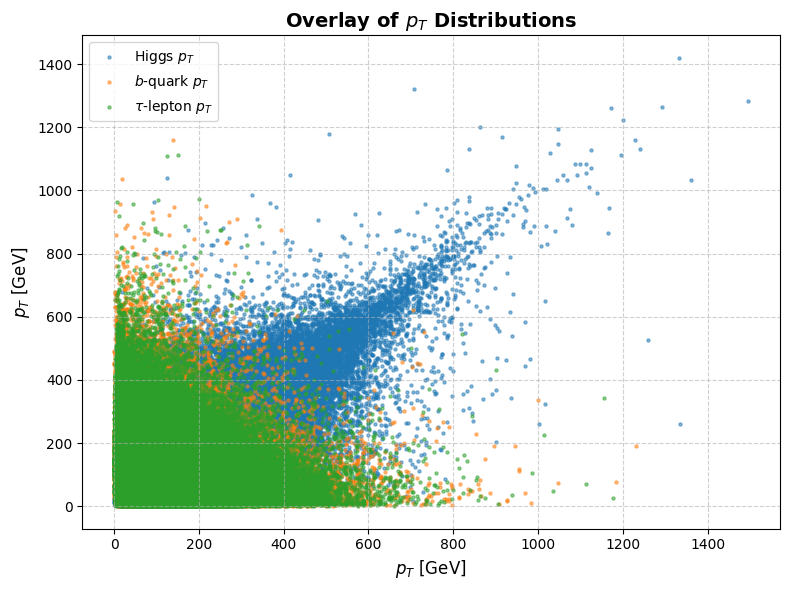

In [12]:
plt.figure(figsize=(8, 6)) 
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(higgs1_pt, higgs2_pt, alpha=0.5, marker="o", s=5, 
           label="Higgs $p_T$")
ax.scatter(b1_pt, b2_pt, alpha=0.5, marker="o", s=5, 
           label="$b$-quark $p_T$")
ax.scatter(Tau1_pt, Tau2_pt, alpha=0.5, marker="o", s=5, 
           label=r"$\tau$-lepton $p_T$")

ax.set_xlabel(r"$p_T$ [GeV]", fontsize=12)
ax.set_ylabel(r"$p_T$ [GeV]", fontsize=12)
ax.set_title("Overlay of $p_T$ Distributions", fontsize=14, fontweight='bold')

ax.legend(frameon=True, loc="upper left", fontsize=10)
ax.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout() 
plt.show()

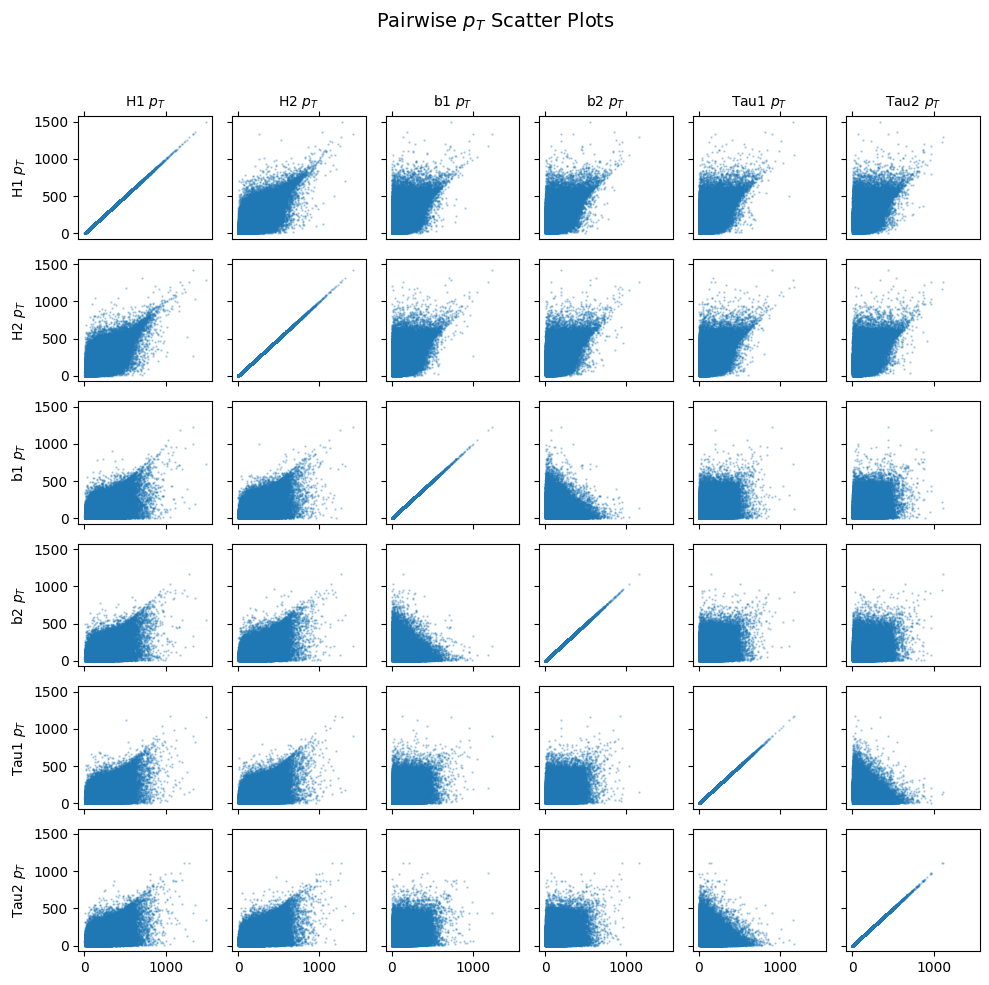

In [13]:
variables = {
    "H1": higgs1_pt,
    "H2": higgs2_pt,
    "b1": b1_pt,
    "b2": b2_pt,
    "Tau1": Tau1_pt,
    "Tau2": Tau2_pt
}

labels = list(variables.keys())
num_vars = len(labels)

data = {key: np.array(value) for key, value in variables.items()}

fig, axes = plt.subplots(num_vars, num_vars, figsize=(10, 10), 
                         sharex=True, sharey=True)

for i in range(num_vars):
    for j in range(num_vars):
        ax = axes[i, j]
        ax.scatter(data[labels[j]], data[labels[i]], alpha=0.3, 
                   marker=".", s=2)  
        if j == 0:
            ax.set_ylabel(f"{labels[i]} $p_T$")

        if i == 0:
            ax.set_xlabel(f"{labels[j]} $p_T$")
            ax.xaxis.set_label_position('top')  
            ax.xaxis.tick_top()  
        ax.grid(False)  

plt.suptitle("Pairwise $p_T$ Scatter Plots", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [14]:
mask = ~((df[('GenHiggsChildren', 0)] == 5) & (df[('GenHiggsChildren', 1)] == 15) 
        | (df[('GenHiggsChildren', 0)] == 15) & (df[('GenHiggsChildren', 1)] == 5)
        )

non_matching = df.loc[mask, [('GenHiggsChildren', 0), ('GenHiggsChildren', 1)]].head(1)

if not non_matching.empty:
    print(non_matching.values[0])
else:
    print("No non-matching events found.")


No non-matching events found.


True Positives (Correctly detected b-quarks): 38727
False Positives (Misidentified non-b as b): 0
True Negatives (Correctly rejected non-b): 0
False Negatives (Missed b-quarks): 815315

Precision: 1.00
Recall (Sensitivity): 0.05
Accuracy: 0.05


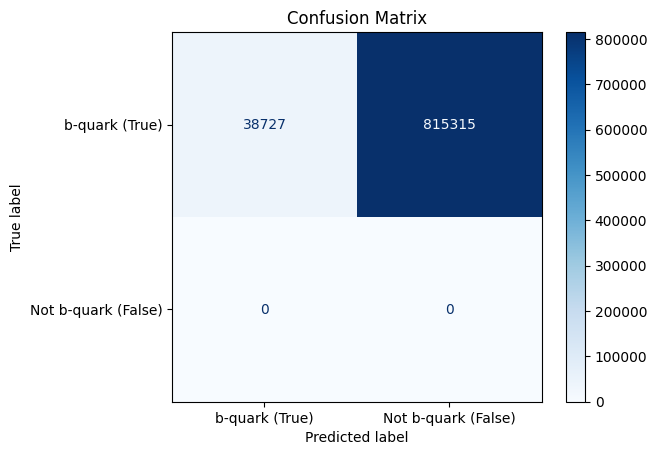

In [15]:
pnetbb = df["HLT_AK8PFJet250_SoftDropMass40_PFAK8ParticleNetBB0p35"][0]
has_b_quark_children = ((df[('GenHiggsChildren', 0)] == 5) 
                        | (df[('GenHiggsChildren', 1)] == 5)
                        )

'''
Here we are trying to look at how many of the Higgs children 
when producess b quark and we also have a simulatanous True signal in the pnetbb trigger 
'''

TP = 0
FP = 0
TN = 0
FN = 0

for i in range(len(df)):
    if pnetbb[i] and has_b_quark_children[i]:
        TP += 1
    if pnetbb[i] and not has_b_quark_children[i]:
        FP += 1
    if not pnetbb[i] and not has_b_quark_children[i]:
        TN += 1
    if not pnetbb[i] and has_b_quark_children[i]:
        FN += 1


print(f"True Positives (Correctly detected b-quarks): {TP}")
print(f"False Positives (Misidentified non-b as b): {FP}")
print(f"True Negatives (Correctly rejected non-b): {TN}")
print(f"False Negatives (Missed b-quarks): {FN}")
print()

# Additional metrics
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
accuracy = (TP + TN) / nEvents if nEvents > 0 else 0

print(f"Precision: {precision:.2f}")
print(f"Recall (Sensitivity): {recall:.2f}")
print(f"Accuracy: {accuracy:.2f}")


cm = confusion_matrix(has_b_quark_children, pnetbb, labels=[1, 0])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                            display_labels=["b-quark (True)", "Not b-quark (False)"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [ ]:
def Trigger_on_simulation(Trigger_in_Test, true_event):

    Higgs_Pt_bin = np.linspace(0, 1400, 300)
    precision_list = []
    recall_list = []
    accuracy_list = []
    retention_rate_list = []

    total_events = len(df)

    for Higgs_Pt_threshold in Higgs_Pt_bin:
        valid_higgs = (
            (df[('GenHiggsPt', 0)] >= Higgs_Pt_threshold) &
            (df[('GenHiggsPt', 1)] >= Higgs_Pt_threshold)
        )

        filtered_trigger_event = Trigger_in_Test[valid_higgs]
        filtered_true_event = true_event[valid_higgs]

        TP = np.sum(filtered_trigger_event & filtered_true_event)  
        FP = np.sum(filtered_trigger_event & ~filtered_true_event) 
        TN = np.sum(~filtered_trigger_event & ~filtered_true_event)  
        FN = np.sum(~filtered_trigger_event & filtered_true_event)  

        tot_count = len(filtered_trigger_event)
        precision = TP / (TP + FP) if (TP + FP) > 0 else 0
        recall = TP / (TP + FN) if (TP + FN) > 0 else 0
        accuracy = (TP + TN) / tot_count if tot_count > 0 else 0

        retention_rate = tot_count / total_events if total_events > 0 else 0

        precision_list.append(precision)
        recall_list.append(recall)
        accuracy_list.append(accuracy)
        retention_rate_list.append(retention_rate)

    return precision_list, recall_list, accuracy_list, retention_rate_list


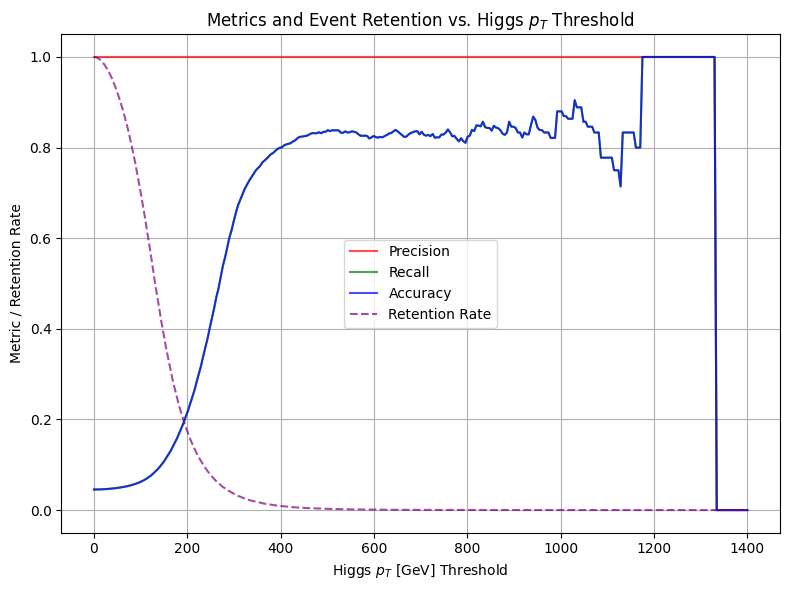

In [17]:
Higgs_Pt_bin = np.linspace(0, 1400, 300)
precision_list = []
recall_list = []
accuracy_list = []
retention_rate_list = []

total_events = len(df)

for Higgs_Pt_threshold in Higgs_Pt_bin:
    valid_higgs = (
        (df[('GenHiggsPt', 0)] >= Higgs_Pt_threshold) &
        (df[('GenHiggsPt', 1)] >= Higgs_Pt_threshold)
    )

    filtered_pnetbb = pnetbb[valid_higgs]
    filtered_b_children = has_b_quark_children[valid_higgs]

    TP = np.sum(filtered_pnetbb & filtered_b_children)  
    FP = np.sum(filtered_pnetbb & ~filtered_b_children) 
    TN = np.sum(~filtered_pnetbb & ~filtered_b_children)  
    FN = np.sum(~filtered_pnetbb & filtered_b_children)  

    tot_count = len(filtered_pnetbb)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    accuracy = (TP + TN) / tot_count if tot_count > 0 else 0

    retention_rate = tot_count / total_events if total_events > 0 else 0

    precision_list.append(precision)
    recall_list.append(recall)
    accuracy_list.append(accuracy)
    retention_rate_list.append(retention_rate)

plt.figure(figsize=(8, 6))
plt.plot(Higgs_Pt_bin, precision_list, linestyle='-', color='r', alpha=0.7, label='Precision')
plt.plot(Higgs_Pt_bin, recall_list, linestyle='-', color='g', alpha=0.7, label='Recall')
plt.plot(Higgs_Pt_bin, accuracy_list, linestyle='-', color='b', alpha=0.7, label='Accuracy')
plt.plot(Higgs_Pt_bin, retention_rate_list, linestyle='--', color='purple', alpha=0.7, label='Retention Rate')

plt.legend()
plt.xlabel("Higgs $p_T$ [GeV] Threshold")
plt.ylabel("Metric / Retention Rate")
plt.title("Metrics and Event Retention vs. Higgs $p_T$ Threshold")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Tau triggers Run 3 https://twiki.cern.ch/twiki/bin/view/CMSPublic/Run3TauHLT

pnetbb = df["HLT_AK8PFJet250_SoftDropMass40_PFAK8ParticleNetBB0p35"][0]
pnettt = df["HLT_AK8PFJet230_SoftDropMass40_PFAK8ParticleNetTauTau0p30"][0]
pnet = pnetbb | pnettt

singletau = df["HLT_LooseDeepTauPFTauHPS180_L2NN_eta2p1"][0]

pfjet = df["HLT_AK8PFJet425_SoftDropMass40"][0]

quadjet = (
    df["HLT_QuadPFJet70_50_40_35_PFBTagParticleNet_2BTagSum0p65"][0]
    | df["HLT_QuadPFJet103_88_75_15_PFBTagDeepJet_1p3_VBF2"][0]
    | df["HLT_QuadPFJet103_88_75_15_DoublePFBTagDeepJet_1p3_7p7_VBF1"][0]
)

ditau = (
    df["HLT_DoubleMediumDeepTauPFTauHPS35_L2NN_eta2p1"][0]
    # | df["HLT_DoubleMediumDeepTauIsoPFTauHPS30_L2NN_eta2p1_PFJet60"][0]
    | df["HLT_DoubleMediumDeepTauPFTauHPS30_L2NN_eta2p1_PFJet60"][0]
    | df["HLT_DoubleMediumDeepTauPFTauHPS30_L2NN_eta2p1_PFJet75"][0]
)

singlemuon = df["HLT_IsoMu24"][0] | df["HLT_Mu50"][0]

mutau = (
    df["HLT_IsoMu20_eta2p1_LooseDeepTauPFTauHPS27_eta2p1_CrossL1"][0]
    | df["HLT_IsoMu24_eta2p1_LooseDeepTauPFTauHPS180_eta2p1"][0]
    | df["HLT_IsoMu24_eta2p1_LooseDeepTauPFTauHPS30_eta2p1_CrossL1"][0]
    | df["HLT_IsoMu24_eta2p1_MediumDeepTauPFTauHPS35_L2NN_eta2p1_CrossL1"][0]
    | df["HLT_IsoMu24_eta2p1_MediumDeepTauPFTauHPS30_L2NN_eta2p1_CrossL1"][0]
    | df["HLT_IsoMu24_eta2p1_MediumDeepTauPFTauHPS45_L2NN_eta2p1_CrossL1"][0]
    | df["HLT_IsoMu20_eta2p1_TightChargedIsoPFTauHPS27_eta2p1_CrossL1"][0]
    | df["HLT_IsoMu20_eta2p1_TightChargedIsoPFTauHPS27_eta2p1_TightID_CrossL1"][0]
)

egamma = (
    df["HLT_Ele30_WPTight_Gsf"][0]
    | df["HLT_Ele115_CaloIdVT_GsfTrkIdT"][0]
    | df["HLT_Ele50_CaloIdVT_GsfTrkIdT_PFJet165"][0]
    | df["HLT_Photon200"][0]
)

etau = (
    df["HLT_Ele24_eta2p1_WPTight_Gsf_LooseDeepTauPFTauHPS30_eta2p1_CrossL1"][0]
    | df["HLT_Ele24_eta2p1_WPTight_Gsf_TightChargedIsoPFTauHPS30_eta2p1_CrossL1"][0]
)

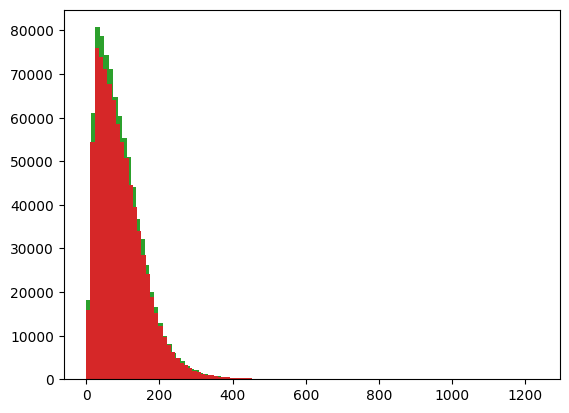

In [19]:
mask = df[('GenHiggsChildren', 0)] != 5
plt_list = df.loc[mask, ('GenbbPt', 0)]
plt.hist(plt_list, bins=100)

mask = df[('GenHiggsChildren', 1)] != 5
plt_list = df.loc[mask, ('GenbbPt', 1)]
plt.hist(plt_list, bins=100)

plt.hist(df["GenbbPt"][0], bins=100)
plt.hist(df["GenbbPt"][1], bins=100)

plt.show()


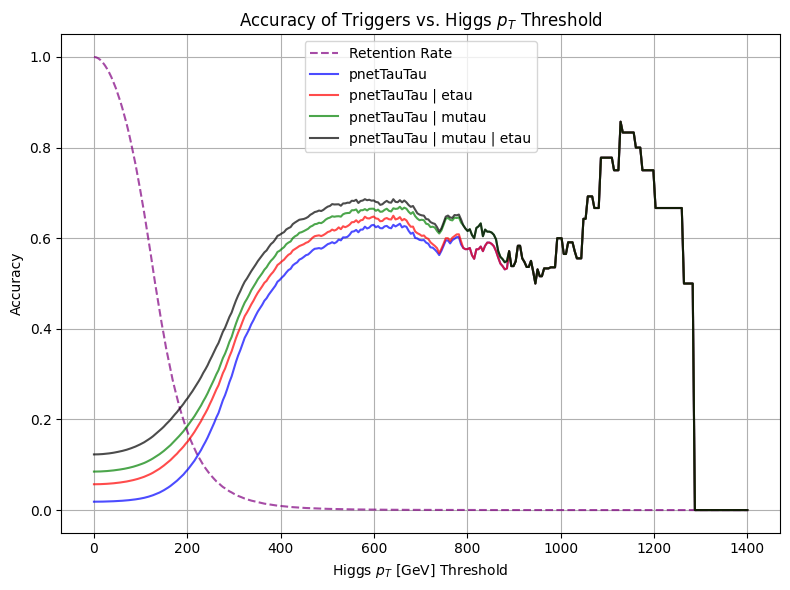

In [20]:
has_tau_quark_children = ((df[('GenHiggsChildren', 0)] == 15) 
                        | (df[('GenHiggsChildren', 1)] == 15)
                        )
                        
pnetTauTau = df["HLT_AK8PFJet230_SoftDropMass40_PFAK8ParticleNetTauTau0p30"][0]

plt.figure(figsize=(8, 6))

Trigger_in_Test = (
    pnetTauTau
)

label_string = "pnetTauTau"

_, _, accuracy_list, retention_rate_list = Trigger_on_simulation(Trigger_in_Test, has_tau_quark_children)
plt.plot(Higgs_Pt_bin, retention_rate_list, linestyle='--', color='purple', alpha=0.7, label='Retention Rate')
plt.plot(Higgs_Pt_bin, accuracy_list, linestyle='-', color='b', alpha=0.7, label=label_string)


Trigger_in_Test = (
    pnetTauTau
    | mutau
)



Trigger_in_Test = (
    pnetTauTau
    | etau
)

label_string = "pnetTauTau | etau"

_, _, accuracy_list, _ = Trigger_on_simulation(Trigger_in_Test, has_tau_quark_children)
plt.plot(Higgs_Pt_bin, accuracy_list, linestyle='-', color='r', alpha=0.7, label=label_string)


Trigger_in_Test = (
    pnetTauTau
    | mutau
)

label_string = "pnetTauTau | mutau "

_, _, accuracy_list, _ = Trigger_on_simulation(Trigger_in_Test, has_tau_quark_children)
plt.plot(Higgs_Pt_bin, accuracy_list, linestyle='-', color='g', alpha=0.7, label=label_string)


Trigger_in_Test = (
    pnetTauTau
    | mutau
    | etau
)

label_string = "pnetTauTau | mutau | etau"

_, _, accuracy_list, _ = Trigger_on_simulation(Trigger_in_Test, has_tau_quark_children)
plt.plot(Higgs_Pt_bin, accuracy_list, linestyle='-', color='black', alpha=0.7, label=label_string)



plt.legend()
plt.xlabel("Higgs $p_T$ [GeV] Threshold")
plt.ylabel("Accuracy")
plt.title("Accuracy of Triggers vs. Higgs $p_T$ Threshold")
plt.grid(True)
plt.tight_layout()
plt.show()

In [21]:
set(df["GenHiggsChildren"][1])

{5, 15}

In [22]:
Higgs_Pt_threshold = 250 # GeV

valid_higgs = (df[('GenHiggsPt', 0)] >= Higgs_Pt_threshold) & \
              (df[('GenHiggsPt', 1)] >= Higgs_Pt_threshold)

# The rest of the conditions are not needed
bb_high = (df[('GenbbPt', 0)] >= Higgs_Pt_threshold) & \
          (df[('GenbbPt', 1)] >= Higgs_Pt_threshold)

bb_low = (df[('GenbbPt', 0)] < Higgs_Pt_threshold) & \
         (df[('GenbbPt', 1)] < Higgs_Pt_threshold)

tau_high = (df[('GenTauPt', 0)] >= Higgs_Pt_threshold) & \
           (df[('GenTauPt', 1)] >= Higgs_Pt_threshold)

tau_low = (df[('GenTauPt', 0)] < Higgs_Pt_threshold) & \
          (df[('GenTauPt', 1)] < Higgs_Pt_threshold)

BbbBtautau = np.sum(valid_higgs & bb_high & tau_high)
BbbRtautau = np.sum(valid_higgs & bb_high & tau_low)
RbbBtautau = np.sum(valid_higgs & bb_low & tau_high)
RbbRtautau = np.sum(valid_higgs & bb_low & tau_low)

print("BbbBtautau:", BbbBtautau)
print("BbbRtautau:", BbbRtautau)
print("RbbBtautau:", RbbBtautau)
print("RbbRtautau:", RbbRtautau)

BbbBtautau: 101
BbbRtautau: 29
RbbBtautau: 38
RbbRtautau: 19465


In [23]:

Higgs_Pt_bin = np.linspace(0, 1400, 300)

BbbBtautau_list = []
BbbRtautau_list = []
RbbBtautau_list = []
RbbRtautau_list = []

for Higgs_Pt_threshold in Higgs_Pt_bin:
    valid_higgs = (df[('GenHiggsPt', 0)] >= Higgs_Pt_threshold) & \
                  (df[('GenHiggsPt', 1)] >= Higgs_Pt_threshold)

    bb_high = (df[('GenbbPt', 0)] >= Higgs_Pt_threshold) & \
              (df[('GenbbPt', 1)] >= Higgs_Pt_threshold)

    bb_low = (df[('GenbbPt', 0)] < Higgs_Pt_threshold) & \
             (df[('GenbbPt', 1)] < Higgs_Pt_threshold)

    tau_high = (df[('GenTauPt', 0)] >= Higgs_Pt_threshold) & \
               (df[('GenTauPt', 1)] >= Higgs_Pt_threshold)

    tau_low = (df[('GenTauPt', 0)] < Higgs_Pt_threshold) & \
              (df[('GenTauPt', 1)] < Higgs_Pt_threshold)

    BbbBtautau_list.append(np.sum(valid_higgs & bb_high & tau_high))
    BbbRtautau_list.append(np.sum(valid_higgs & bb_high & tau_low))
    RbbBtautau_list.append(np.sum(valid_higgs & bb_low & tau_high))
    RbbRtautau_list.append(np.sum(valid_higgs & bb_low & tau_low))

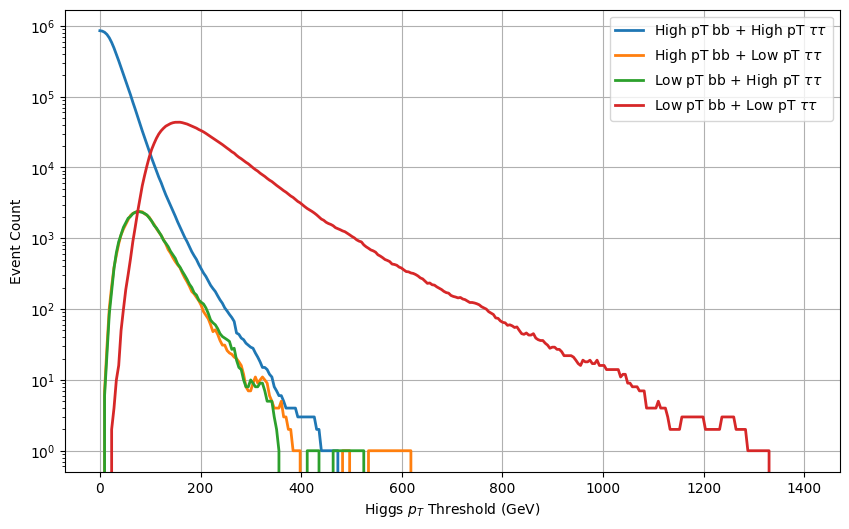

In [24]:
plt.figure(figsize=(10, 6))
plt.plot(Higgs_Pt_bin, BbbBtautau_list, label=r"High pT bb + High pT $\tau\tau$", linewidth=2)
plt.plot(Higgs_Pt_bin, BbbRtautau_list, label=r"High pT bb + Low pT $\tau\tau$", linewidth=2)
plt.plot(Higgs_Pt_bin, RbbBtautau_list, label=r"Low pT bb + High pT $\tau\tau$", linewidth=2)
plt.plot(Higgs_Pt_bin, RbbRtautau_list, label=r"Low pT bb + Low pT $\tau\tau$", linewidth=2)

plt.xlabel("Higgs $p_T$ Threshold (GeV)")
plt.ylabel("Event Count")
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.show()

In [25]:
# Boosted eans their delta R is less than some threshold
# Now define them here

import numpy as np

Higgs_Pt_bin = np.linspace(0, 1400, 300)

BbbBtautau_list = []
BbbRtautau_list = []
RbbBtautau_list = []
RbbRtautau_list = []

# Channge the valid Higgs 
deltaR_threshold = 1.2 
for Higgs_Pt_threshold in Higgs_Pt_bin:
    valid_higgs = (df[('GenHiggsPt', 0)] >= Higgs_Pt_threshold) & \
                  (df[('GenHiggsPt', 1)] >= Higgs_Pt_threshold)

    deltaR_bb = np.sqrt((df[('GenbbEta', 0)] - df[('GenbbEta', 1)])**2 +
                         (df[('GenbbPhi', 0)] - df[('GenbbPhi', 1)])**2)

    deltaR_tau = np.sqrt((df[('GenTauEta', 0)] - df[('GenTauEta', 1)])**2 +
                          (df[('GenTauPhi', 0)] - df[('GenTauPhi', 1)])**2)

    # Boosted and Resolved
    bb_boosted = deltaR_bb < deltaR_threshold
    bb_resolved = deltaR_bb >= deltaR_threshold
    tau_boosted = deltaR_tau < deltaR_threshold
    tau_resolved = deltaR_tau >= deltaR_threshold

    BbbBtautau_list.append(np.sum(valid_higgs & bb_boosted & tau_boosted))
    BbbRtautau_list.append(np.sum(valid_higgs & bb_boosted & tau_resolved)) # 
    RbbBtautau_list.append(np.sum(valid_higgs & bb_resolved & tau_boosted))
    RbbRtautau_list.append(np.sum(valid_higgs & bb_resolved & tau_resolved))

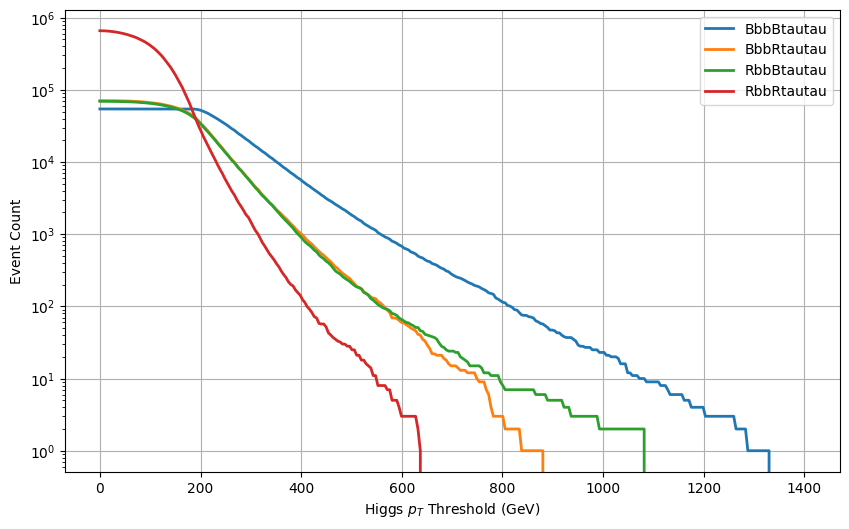

In [26]:
plt.figure(figsize=(10, 6))
plt.plot(Higgs_Pt_bin, BbbBtautau_list, label="BbbBtautau", linewidth=2)
plt.plot(Higgs_Pt_bin, BbbRtautau_list, label="BbbRtautau", linewidth=2)
plt.plot(Higgs_Pt_bin, RbbBtautau_list, label="RbbBtautau", linewidth=2)
plt.plot(Higgs_Pt_bin, RbbRtautau_list, label="RbbRtautau", linewidth=2)

plt.xlabel("Higgs $p_T$ Threshold (GeV)")
plt.ylabel("Event Count")
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.show()

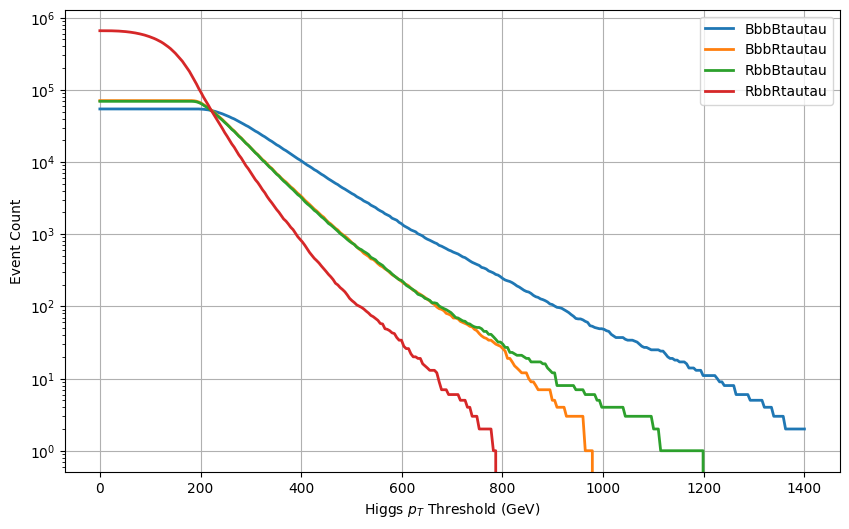

In [27]:
# Atleast one of Higgs is boosted to pass the Boosted Higgs criteria

Higgs_Pt_bin = np.linspace(0, 1400, 300)

BbbBtautau_list = []
BbbRtautau_list = []
RbbBtautau_list = []
RbbRtautau_list = []

# Channge the valid Higgs 
deltaR_threshold = 1.2 
for Higgs_Pt_threshold in Higgs_Pt_bin:
    valid_higgs = (df[('GenHiggsPt', 0)] >= Higgs_Pt_threshold) | \
                  (df[('GenHiggsPt', 1)] >= Higgs_Pt_threshold)

    deltaR_bb = np.sqrt((df[('GenbbEta', 0)] - df[('GenbbEta', 1)])**2 +
                         (df[('GenbbPhi', 0)] - df[('GenbbPhi', 1)])**2)

    deltaR_tau = np.sqrt((df[('GenTauEta', 0)] - df[('GenTauEta', 1)])**2 +
                          (df[('GenTauPhi', 0)] - df[('GenTauPhi', 1)])**2)

    # Boosted and Resolved
    bb_boosted = deltaR_bb < deltaR_threshold
    bb_resolved = deltaR_bb >= deltaR_threshold
    tau_boosted = deltaR_tau < deltaR_threshold
    tau_resolved = deltaR_tau >= deltaR_threshold

    BbbBtautau_list.append(np.sum(valid_higgs & bb_boosted & tau_boosted))
    BbbRtautau_list.append(np.sum(valid_higgs & bb_boosted & tau_resolved)) # 
    RbbBtautau_list.append(np.sum(valid_higgs & bb_resolved & tau_boosted))
    RbbRtautau_list.append(np.sum(valid_higgs & bb_resolved & tau_resolved))


plt.figure(figsize=(10, 6))
plt.plot(Higgs_Pt_bin, BbbBtautau_list, label="BbbBtautau", linewidth=2)
plt.plot(Higgs_Pt_bin, BbbRtautau_list, label="BbbRtautau", linewidth=2)
plt.plot(Higgs_Pt_bin, RbbBtautau_list, label="RbbBtautau", linewidth=2)
plt.plot(Higgs_Pt_bin, RbbRtautau_list, label="RbbRtautau", linewidth=2)

plt.xlabel("Higgs $p_T$ Threshold (GeV)")
plt.ylabel("Event Count")
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.show()

In [28]:
H1_Pt = df[('GenHiggsPt', 0)].to_numpy()
H2_Pt = df[('GenHiggsPt', 1)].to_numpy()
H1_children = df[('GenHiggsChildren', 0)].to_numpy()
H2_children = df[('GenHiggsChildren', 1)].to_numpy()

deltaR_bb = np.sqrt((df[('GenbbEta', 0)] - df[('GenbbEta', 1)])**2 +
                        (df[('GenbbPhi', 0)] - df[('GenbbPhi', 1)])**2)

deltaR_tau = np.sqrt((df[('GenTauEta', 0)] - df[('GenTauEta', 1)])**2 +
                        (df[('GenTauPhi', 0)] - df[('GenTauPhi', 1)])**2)


deltaR_bb_arr = deltaR_bb.to_numpy()
deltaR_tau_arr = deltaR_tau.to_numpy()

In [29]:
BbbBtautau_list = []
BbbRtautau_list = []
RbbBtautau_list = []
RbbRtautau_list = []

deltaR_threshold = 1.2  

for Higgs_Pt_threshold in Higgs_Pt_bin:
    boosted_H1 = H1_Pt >= Higgs_Pt_threshold
    boosted_H2 = H2_Pt >= Higgs_Pt_threshold
    resolved_H1 = ~boosted_H1  
    resolved_H2 = ~boosted_H2

    # Identify Higgs decaying into bb or tautau pairs
    H1_has_bb = H1_children == 5
    H2_has_bb = H2_children == 5
    H1_has_TauTau = H1_children == 15
    H2_has_TauTau = H2_children == 15

    # Determine if decay products are close (boosted) or well-separated (resolved)
    boosted_bb = deltaR_bb < deltaR_threshold
    resolved_bb = deltaR_bb >= deltaR_threshold

    boosted_tau = deltaR_tau < deltaR_threshold
    resolved_tau = deltaR_tau >= deltaR_threshold

    # Count events where Higgs 1 decays into bb and Higgs 2 decays into tautau
    BbbBtautau = np.sum(
        (boosted_H1 & H1_has_bb) &  # Higgs 1 is boosted and decays into bb
        (boosted_H2 & H2_has_TauTau) &  # Higgs 2 is boosted and decays into tautau
        (boosted_bb & boosted_tau)  # Both decay products are close (boosted)
    )

    BbbRtautau = np.sum(
        (boosted_H1 & H1_has_bb) & 
        (resolved_H2 & H2_has_TauTau) & 
        (boosted_bb & resolved_tau)  # bb is boosted, tautau is resolved
    )

    RbbBtautau = np.sum(
        (resolved_H1 & H1_has_bb) & 
        (boosted_H2 & H2_has_TauTau) & 
        (resolved_bb & boosted_tau)  # bb is resolved, tautau is boosted
    )

    RbbRtautau = np.sum(
        (resolved_H1 & H1_has_bb) & 
        (resolved_H2 & H2_has_TauTau) & 
        (resolved_bb & resolved_tau)  # Both decay products are resolved
    )

    # Now consider the opposite case: Higgs 1 decays into tautau, Higgs 2 decays into bb
    BbbBtautau += np.sum(
        (boosted_H1 & H1_has_TauTau) & 
        (boosted_H2 & H2_has_bb) & 
        (boosted_tau & boosted_bb)
    )

    BbbRtautau += np.sum(
        (boosted_H1 & H1_has_TauTau) & 
        (resolved_H2 & H2_has_bb) & 
        (boosted_tau & resolved_bb)
    )

    RbbBtautau += np.sum(
        (resolved_H1 & H1_has_TauTau) & 
        (boosted_H2 & H2_has_bb) & 
        (resolved_tau & boosted_bb)
    )

    RbbRtautau += np.sum(
        (resolved_H1 & H1_has_TauTau) & 
        (resolved_H2 & H2_has_bb) & 
        (resolved_tau & resolved_bb)
    )

    BbbBtautau_list.append(BbbBtautau)
    BbbRtautau_list.append(BbbRtautau)
    RbbBtautau_list.append(RbbBtautau)
    RbbRtautau_list.append(RbbRtautau)


In [30]:
BbbBtautau_list = []
BbbRtautau_list = []
RbbBtautau_list = []
RbbRtautau_list = []

deltaR_threshold = 1.2  

for Higgs_Pt_threshold in Higgs_Pt_bin:
    boosted_H1 = H1_Pt >= Higgs_Pt_threshold
    boosted_H2 = H2_Pt >= Higgs_Pt_threshold
    both_boosted = boosted_H1 & boosted_H2  # Ensure both Higgs are boosted

    # Skip if neither Higgs pair is fully boosted
    if not np.any(both_boosted):
        BbbBtautau_list.append(0)
        BbbRtautau_list.append(0)
        RbbBtautau_list.append(0)
        RbbRtautau_list.append(0)
        continue  # Skip this threshold

    # Identify Higgs decaying into bb or tautau pairs
    H1_has_bb = H1_children == 5
    H2_has_bb = H2_children == 5
    H1_has_TauTau = H1_children == 15
    H2_has_TauTau = H2_children == 15

    # Determine if decay products are close (boosted) or well-separated (resolved)
    boosted_bb = deltaR_bb < deltaR_threshold
    resolved_bb = deltaR_bb >= deltaR_threshold
    boosted_tau = deltaR_tau < deltaR_threshold
    resolved_tau = deltaR_tau >= deltaR_threshold

    # Initialize counts
    BbbBtautau, BbbRtautau, RbbBtautau, RbbRtautau = 0, 0, 0, 0

    # Only compute sums where both Higgs are boosted
    if np.any(both_boosted):
        BbbBtautau = np.sum(
            (both_boosted & H1_has_bb) & (both_boosted & H2_has_TauTau) & (boosted_bb & boosted_tau)
        )
        BbbRtautau = np.sum(
            (both_boosted & H1_has_bb) & (both_boosted & H2_has_TauTau) & (boosted_bb & resolved_tau)
        )
        RbbBtautau = np.sum(
            (both_boosted & H1_has_bb) & (both_boosted & H2_has_TauTau) & (resolved_bb & boosted_tau)
        )
        RbbRtautau = np.sum(
            (both_boosted & H1_has_bb) & (both_boosted & H2_has_TauTau) & (resolved_bb & resolved_tau)
        )

        # Consider opposite case: H1 → ττ, H2 → bb
        BbbBtautau += np.sum(
            (both_boosted & H1_has_TauTau) & (both_boosted & H2_has_bb) & (boosted_tau & boosted_bb)
        )
        BbbRtautau += np.sum(
            (both_boosted & H1_has_TauTau) & (both_boosted & H2_has_bb) & (boosted_tau & resolved_bb)
        )
        RbbBtautau += np.sum(
            (both_boosted & H1_has_TauTau) & (both_boosted & H2_has_bb) & (resolved_tau & boosted_bb)
        )
        RbbRtautau += np.sum(
            (both_boosted & H1_has_TauTau) & (both_boosted & H2_has_bb) & (resolved_tau & resolved_bb)
        )

    # Store results
    BbbBtautau_list.append(BbbBtautau)
    BbbRtautau_list.append(BbbRtautau)
    RbbBtautau_list.append(RbbBtautau)
    RbbRtautau_list.append(RbbRtautau)


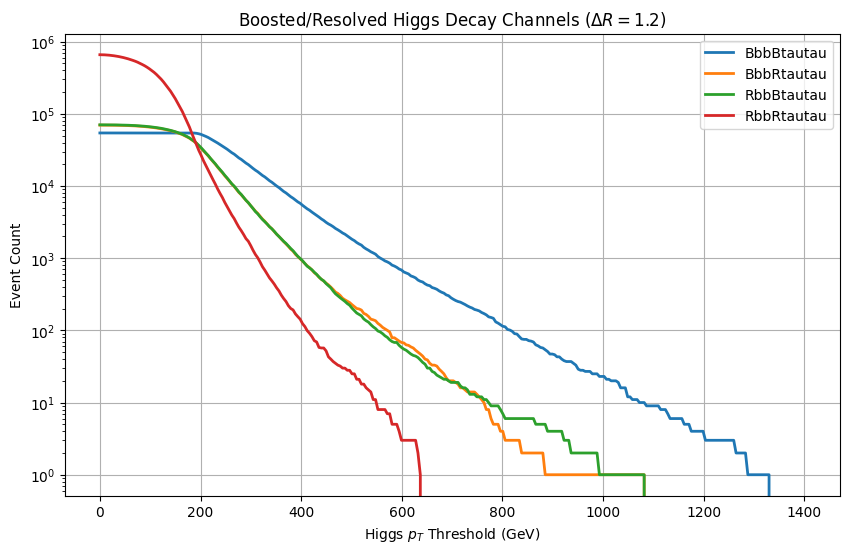

In [31]:

plt.figure(figsize=(10, 6))
plt.plot(Higgs_Pt_bin, BbbBtautau_list, label="BbbBtautau", linewidth=2)
plt.plot(Higgs_Pt_bin, BbbRtautau_list, label="BbbRtautau", linewidth=2)
plt.plot(Higgs_Pt_bin, RbbBtautau_list, label="RbbBtautau", linewidth=2)
plt.plot(Higgs_Pt_bin, RbbRtautau_list, label="RbbRtautau", linewidth=2)


plt.xlabel("Higgs $p_T$ Threshold (GeV)")
plt.ylabel("Event Count")
plt.yscale('log') 
plt.title(fr"Boosted/Resolved Higgs Decay Channels ($\Delta R = {deltaR_threshold}$)")
plt.legend()
plt.grid(True)
plt.show()


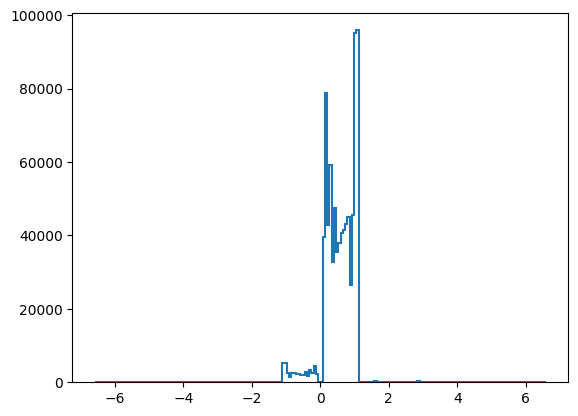

In [32]:
plt.hist(df[('weight', 0)], bins=200, histtype='step', linewidth=1.5, label="Jet 0")
plt.show()

In [ ]:
def classify_higgs_decays(deltaR_threshold = 1.2):

    BbbBtautau_list = []
    BbbRtautau_list = []
    RbbBtautau_list = []
    RbbRtautau_list = []

    deltaR_threshold = 1.2  

    for Higgs_Pt_threshold in Higgs_Pt_bin:
        boosted_H1 = H1_Pt >= Higgs_Pt_threshold
        boosted_H2 = H2_Pt >= Higgs_Pt_threshold
        both_boosted = boosted_H1 | boosted_H2  # Ensure both Higgs are boosted

        # Count total events where both Higgs are boosted
        total_boosted_events = np.sum(both_boosted)

        # Skip if neither Higgs pair is fully boosted
        if not np.any(both_boosted):
            BbbBtautau_list.append(0)
            BbbRtautau_list.append(0)
            RbbBtautau_list.append(0)
            RbbRtautau_list.append(0)
            continue  # Skip this threshold

        # Identify Higgs decaying into bb or tautau pairs
        H1_has_bb = H1_children == 5
        H2_has_bb = H2_children == 5
        H1_has_TauTau = H1_children == 15
        H2_has_TauTau = H2_children == 15

        # Determine if decay products are close (boosted) or well-separated (resolved)
        boosted_bb = deltaR_bb < deltaR_threshold
        resolved_bb = deltaR_bb >= deltaR_threshold
        boosted_tau = deltaR_tau < deltaR_threshold
        resolved_tau = deltaR_tau >= deltaR_threshold

        # Initialize counts
        BbbBtautau, BbbRtautau, RbbBtautau, RbbRtautau = 0, 0, 0, 0

        # Only compute sums where both Higgs are boosted
        if np.any(both_boosted):
            BbbBtautau = np.sum(
                (both_boosted & H1_has_bb) & (both_boosted & H2_has_TauTau) & (boosted_bb & boosted_tau)
            ) / total_boosted_events
            BbbRtautau = np.sum(
                (both_boosted & H1_has_bb) & (both_boosted & H2_has_TauTau) & (boosted_bb & resolved_tau)
            ) / total_boosted_events
            RbbBtautau = np.sum(
                (both_boosted & H1_has_bb) & (both_boosted & H2_has_TauTau) & (resolved_bb & boosted_tau)
            ) / total_boosted_events
            RbbRtautau = np.sum(
                (both_boosted & H1_has_bb) & (both_boosted & H2_has_TauTau) & (resolved_bb & resolved_tau)
            ) / total_boosted_events

            # Consider opposite case: H1 → ττ, H2 → bb
            BbbBtautau += np.sum(
                (both_boosted & H1_has_TauTau) & (both_boosted & H2_has_bb) & (boosted_tau & boosted_bb)
            ) / total_boosted_events
            BbbRtautau += np.sum(
                (both_boosted & H1_has_TauTau) & (both_boosted & H2_has_bb) & (boosted_tau & resolved_bb)
            ) / total_boosted_events
            RbbBtautau += np.sum(
                (both_boosted & H1_has_TauTau) & (both_boosted & H2_has_bb) & (resolved_tau & boosted_bb)
            ) / total_boosted_events
            RbbRtautau += np.sum(
                (both_boosted & H1_has_TauTau) & (both_boosted & H2_has_bb) & (resolved_tau & resolved_bb)
            ) / total_boosted_events

        # Store results
        BbbBtautau_list.append(BbbBtautau)
        BbbRtautau_list.append(BbbRtautau)
        RbbBtautau_list.append(RbbBtautau)
        RbbRtautau_list.append(RbbRtautau)


    return BbbBtautau_list, BbbRtautau_list, RbbBtautau_list, RbbRtautau_list

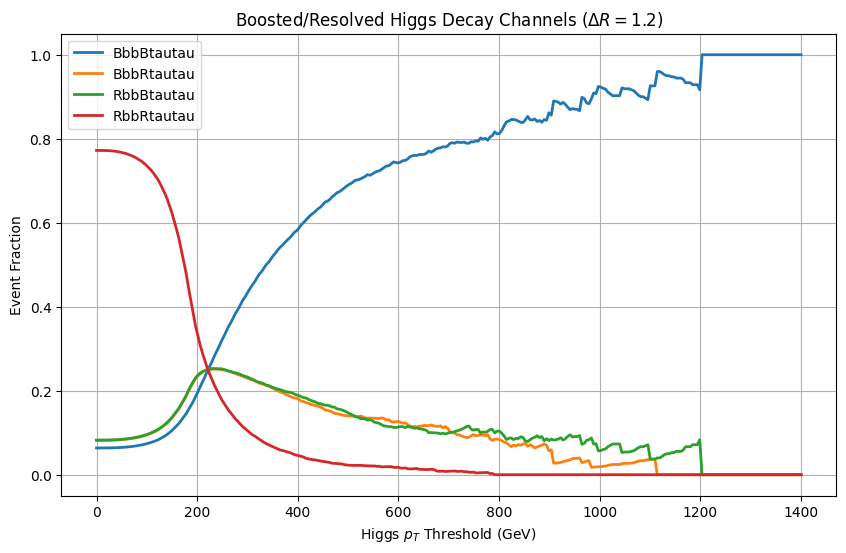

In [34]:
deltaR_threshold = 1.2

BbbBtautau_list, BbbRtautau_list, RbbBtautau_list, RbbRtautau_list = classify_higgs_decays(deltaR_threshold = deltaR_threshold)

plt.figure(figsize=(10, 6))
plt.plot(Higgs_Pt_bin, BbbBtautau_list, label="BbbBtautau", linewidth=2)
plt.plot(Higgs_Pt_bin, BbbRtautau_list, label="BbbRtautau", linewidth=2)
plt.plot(Higgs_Pt_bin, RbbBtautau_list, label="RbbBtautau", linewidth=2)
plt.plot(Higgs_Pt_bin, RbbRtautau_list, label="RbbRtautau", linewidth=2)


plt.xlabel("Higgs $p_T$ Threshold (GeV)")
plt.ylabel("Event Fraction")
# plt.yscale('log') 
plt.title(fr"Boosted/Resolved Higgs Decay Channels ($\Delta R = {deltaR_threshold}$)")
plt.legend()
plt.grid(True)
plt.show()


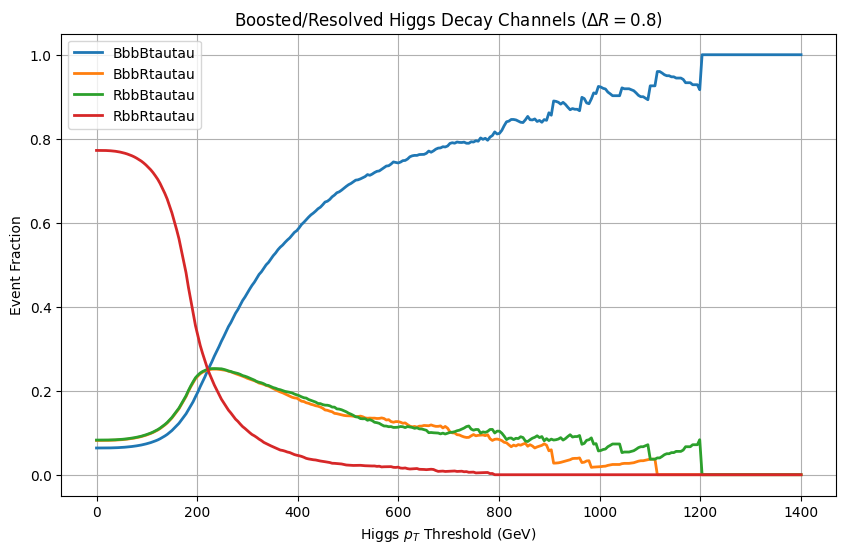

In [35]:
deltaR_threshold = 0.8

BbbBtautau_list, BbbRtautau_list, RbbBtautau_list, RbbRtautau_list = classify_higgs_decays(deltaR_threshold = deltaR_threshold)

plt.figure(figsize=(10, 6))
plt.plot(Higgs_Pt_bin, BbbBtautau_list, label="BbbBtautau", linewidth=2)
plt.plot(Higgs_Pt_bin, BbbRtautau_list, label="BbbRtautau", linewidth=2)
plt.plot(Higgs_Pt_bin, RbbBtautau_list, label="RbbBtautau", linewidth=2)
plt.plot(Higgs_Pt_bin, RbbRtautau_list, label="RbbRtautau", linewidth=2)


plt.xlabel("Higgs $p_T$ Threshold (GeV)")
plt.ylabel("Event Fraction")
# plt.yscale('log') 
plt.title(fr"Boosted/Resolved Higgs Decay Channels ($\Delta R = {deltaR_threshold}$)")
plt.legend()
plt.grid(True)
plt.show()


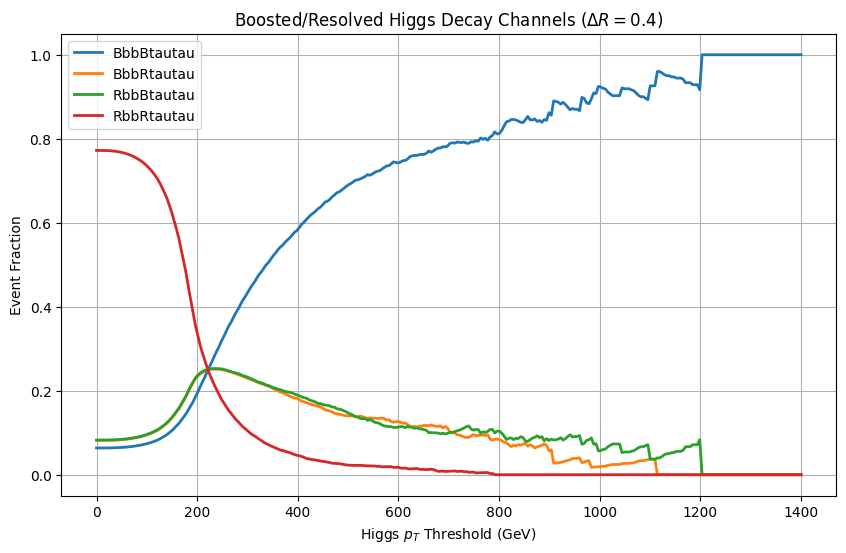

In [36]:
deltaR_threshold = 0.4

BbbBtautau_list, BbbRtautau_list, RbbBtautau_list, RbbRtautau_list = classify_higgs_decays(deltaR_threshold = deltaR_threshold)

plt.figure(figsize=(10, 6))
plt.plot(Higgs_Pt_bin, BbbBtautau_list, label="BbbBtautau", linewidth=2)
plt.plot(Higgs_Pt_bin, BbbRtautau_list, label="BbbRtautau", linewidth=2)
plt.plot(Higgs_Pt_bin, RbbBtautau_list, label="RbbBtautau", linewidth=2)
plt.plot(Higgs_Pt_bin, RbbRtautau_list, label="RbbRtautau", linewidth=2)


plt.xlabel("Higgs $p_T$ Threshold (GeV)")
plt.ylabel("Event Fraction")
# plt.yscale('log') 
plt.title(fr"Boosted/Resolved Higgs Decay Channels ($\Delta R = {deltaR_threshold}$)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# All of the graphs looks very similar, maybe all the events are geting same because of the threshold  filter. 
# Ask Yibo what is the threshold for boosted higgs is a andor or condtion?

In [38]:
weights = df["weight"][0]
higgs = utils.make_vector(df, name="GenHiggs")
mhh = (higgs[:, 0] + higgs[:, 1]).mass
hbbpt = higgs[df["GenHiggsChildren"] == 5].pt
httpt = higgs[df["GenHiggsChildren"] == 15].pt

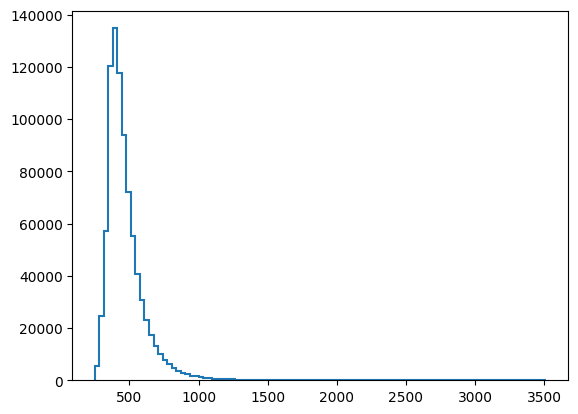

In [39]:
plt.hist(mhh, bins=100, histtype='step', linewidth=1.5)
plt.show()

In [40]:
higgs

MomentumNumpy4D([[( 68.75 , -0.25976562, -2.3203125 , 125.),
                  ( 40.375,  1.0039062 , -1.203125  , 125.)],
                 [(138.   , -1.3007812 , -0.23291016, 125.),
                  (126.75 ,  1.765625  ,  0.6347656 , 125.)],
                 [(225.   , -2.015625  , -0.14648438, 125.),
                  (169.   ,  0.8515625 , -0.28515625, 125.)],
                 ...,
                 [(331.   , -0.8066406 ,  1.28125   , 125.),
                  (227.5  ,  2.6796875 ,  1.390625  , 125.)],
                 [(106.5  ,  2.7890625 ,  2.3671875 , 125.),
                  (155.   , -0.4716797 ,  2.53125   , 125.)],
                 [(239.   , -1.2421875 ,  1.1171875 , 125.),
                  (190.5  ,  1.9921875 ,  2.0078125 , 125.)]],
                dtype=[('rho', '<f4'), ('phi', '<f4'), ('eta', '<f4'), ('tau', '<f4')])

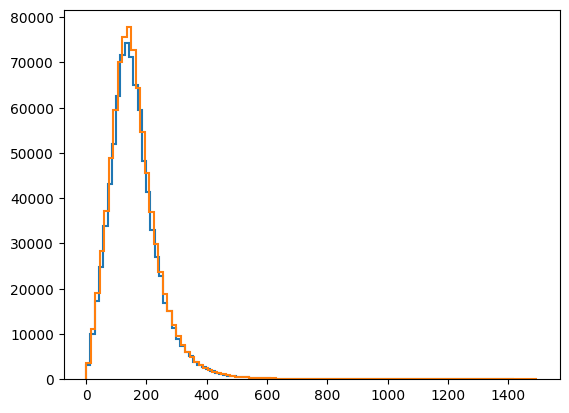

In [41]:
plt.hist(hbbpt, bins=100, histtype='step', linewidth=1.5)
plt.hist(httpt, bins=100, histtype='step', linewidth=1.5)
plt.show()

In [42]:
print("Higgs pt (first 4 events):")
print(higgs.pt[:4])

print("\nGenHiggsChildren == 5 (first 4 events):")
print((df["GenHiggsChildren"] == 5)[:4])

print(f"\nFirst hbb pt (Higgs → bb): {hbbpt[0]:.2f} GeV")
print(f"First htt pt (Higgs → ττ): {httpt[0]:.2f} GeV")


Higgs pt (first 4 events):
[[ 68.75   40.375]
 [138.    126.75 ]
 [225.    169.   ]
 [118.75  120.5  ]]

GenHiggsChildren == 5 (first 4 events):
       0      1
0   True  False
1  False   True
2  False   True
3   True  False

First hbb pt (Higgs → bb): 68.75 GeV
First htt pt (Higgs → ττ): 40.38 GeV


In [43]:
# Tau triggers Run 3 https://twiki.cern.ch/twiki/bin/view/CMSPublic/Run3TauHLT

pnetbb = df["HLT_AK8PFJet250_SoftDropMass40_PFAK8ParticleNetBB0p35"][0]
pnettt = df["HLT_AK8PFJet230_SoftDropMass40_PFAK8ParticleNetTauTau0p30"][0]
pnet = pnetbb | pnettt

singletau = df["HLT_LooseDeepTauPFTauHPS180_L2NN_eta2p1"][0]

pfjet = df["HLT_AK8PFJet425_SoftDropMass40"][0]

quadjet = (
    df["HLT_QuadPFJet70_50_40_35_PFBTagParticleNet_2BTagSum0p65"][0]
    | df["HLT_QuadPFJet103_88_75_15_PFBTagDeepJet_1p3_VBF2"][0]
    | df["HLT_QuadPFJet103_88_75_15_DoublePFBTagDeepJet_1p3_7p7_VBF1"][0]
)

ditau = (
    df["HLT_DoubleMediumDeepTauPFTauHPS35_L2NN_eta2p1"][0]
    | df["HLT_DoubleMediumDeepTauPFTauHPS30_L2NN_eta2p1_PFJet60"][0]
    | df["HLT_DoubleMediumDeepTauPFTauHPS30_L2NN_eta2p1_PFJet75"][0]
)

singlemuon = df["HLT_IsoMu24"][0] | df["HLT_Mu50"][0]

mutau = (
    df["HLT_IsoMu20_eta2p1_LooseDeepTauPFTauHPS27_eta2p1_CrossL1"][0]
    | df["HLT_IsoMu24_eta2p1_LooseDeepTauPFTauHPS180_eta2p1"][0]
    | df["HLT_IsoMu24_eta2p1_LooseDeepTauPFTauHPS30_eta2p1_CrossL1"][0]
    | df["HLT_IsoMu24_eta2p1_MediumDeepTauPFTauHPS35_L2NN_eta2p1_CrossL1"][0]
    | df["HLT_IsoMu24_eta2p1_MediumDeepTauPFTauHPS30_L2NN_eta2p1_CrossL1"][0]
    | df["HLT_IsoMu24_eta2p1_MediumDeepTauPFTauHPS45_L2NN_eta2p1_CrossL1"][0]
    | df["HLT_IsoMu20_eta2p1_TightChargedIsoPFTauHPS27_eta2p1_CrossL1"][0]
    | df["HLT_IsoMu20_eta2p1_TightChargedIsoPFTauHPS27_eta2p1_TightID_CrossL1"][0]
)

egamma = (
    df["HLT_Ele30_WPTight_Gsf"][0]
    | df["HLT_Ele115_CaloIdVT_GsfTrkIdT"][0]
    | df["HLT_Ele50_CaloIdVT_GsfTrkIdT_PFJet165"][0]
    | df["HLT_Photon200"][0]
)

etau = (
    df["HLT_Ele24_eta2p1_WPTight_Gsf_LooseDeepTauPFTauHPS30_eta2p1_CrossL1"][0]
    | df["HLT_Ele24_eta2p1_WPTight_Gsf_TightChargedIsoPFTauHPS30_eta2p1_CrossL1"][0]
)

triggers_dict = {
    "tauhmu": {
        "mask": df["GenTauhmu"][0],
        "label": r"$\tau_h\mu$",
        "triggers": {
            "PNetBB": pnetbb,
            "PNetTauTau": pnettt,
            "PNetBB | TauTau": pnet,
            "Muon": singlemuon,
            "Mu-tau": mutau,
            "SingleTau": singletau,
            "Di-tau": ditau,
            "PNetBB | TauTau | Muon | Mu-tau | SingleTau | Di-tau | PFJet425": pnet
            | singlemuon
            | mutau
            | singletau
            | ditau
            | pfjet,
        },
    },
    "tauhmu_minus": {
        "mask": df["GenTauhmu"][0],
        "label": r"$\tau_h\mu$",
        "triggers": {
            "PNetBB | TauTau | Muon | Mu-tau | SingleTau | Di-tau | PFJet425": pnet
            | singlemuon
            | mutau
            | singletau
            | ditau
            | pfjet,
            "-PNetBB": pnettt | singlemuon | mutau | singletau | ditau | pfjet,
            "-PNetTauTau": pnetbb | singlemuon | mutau | singletau | ditau | pfjet,
            "-Muon": pnet | mutau | singletau | ditau | pfjet,
            "-Mu-tau": pnet | singlemuon | singletau | ditau | pfjet,
            "-SingleTau": pnet | singlemuon | mutau | ditau | pfjet,
            "-Di-tau": pnet | singlemuon | mutau | singletau | pfjet,
            "-PFJet425": pnet | singlemuon | mutau | singletau | ditau,
        },
    },
    "tauhe": {
        "mask": df["GenTauhe"][0],
        "label": r"$\tau_he$",
        "triggers": {
            "PNetBB": pnetbb,
            "PNetTauTau": pnettt,
            "PNetBB | TauTau": pnet,
            "EGamma": egamma,
            "e-tau": etau,
            "SingleTau": singletau,
            "Di-tau": ditau,
            "PNetBB | TauTau | EGamma | e-tau | SingleTau | Di-tau | PFJet425": pnet
            | egamma
            | etau
            | singletau
            | ditau
            | pfjet,
        },
    },
    "tauhe_minus": {
        "mask": df["GenTauhe"][0],
        "label": r"$\tau_he$",
        "triggers": {
            "PNetBB | TauTau | EGamma | e-tau | SingleTau | Di-tau | PFJet425": pnet
            | egamma
            | etau
            | singletau
            | ditau
            | pfjet,
            "-PNetBB": pnettt | egamma | etau | singletau | ditau | pfjet,
            "-PNetTauTau": pnetbb | egamma | etau | singletau | ditau | pfjet,
            "-EGamma": pnet | etau | singletau | ditau | pfjet,
            "-e-tau": pnet | egamma | singletau | ditau | pfjet,
            "-SingleTau": pnet | egamma | etau | ditau | pfjet,
            "-Di-tau": pnet | egamma | etau | singletau | pfjet,
            "-PFJet425": pnet | egamma | etau | singletau | ditau,
        },
    },
}

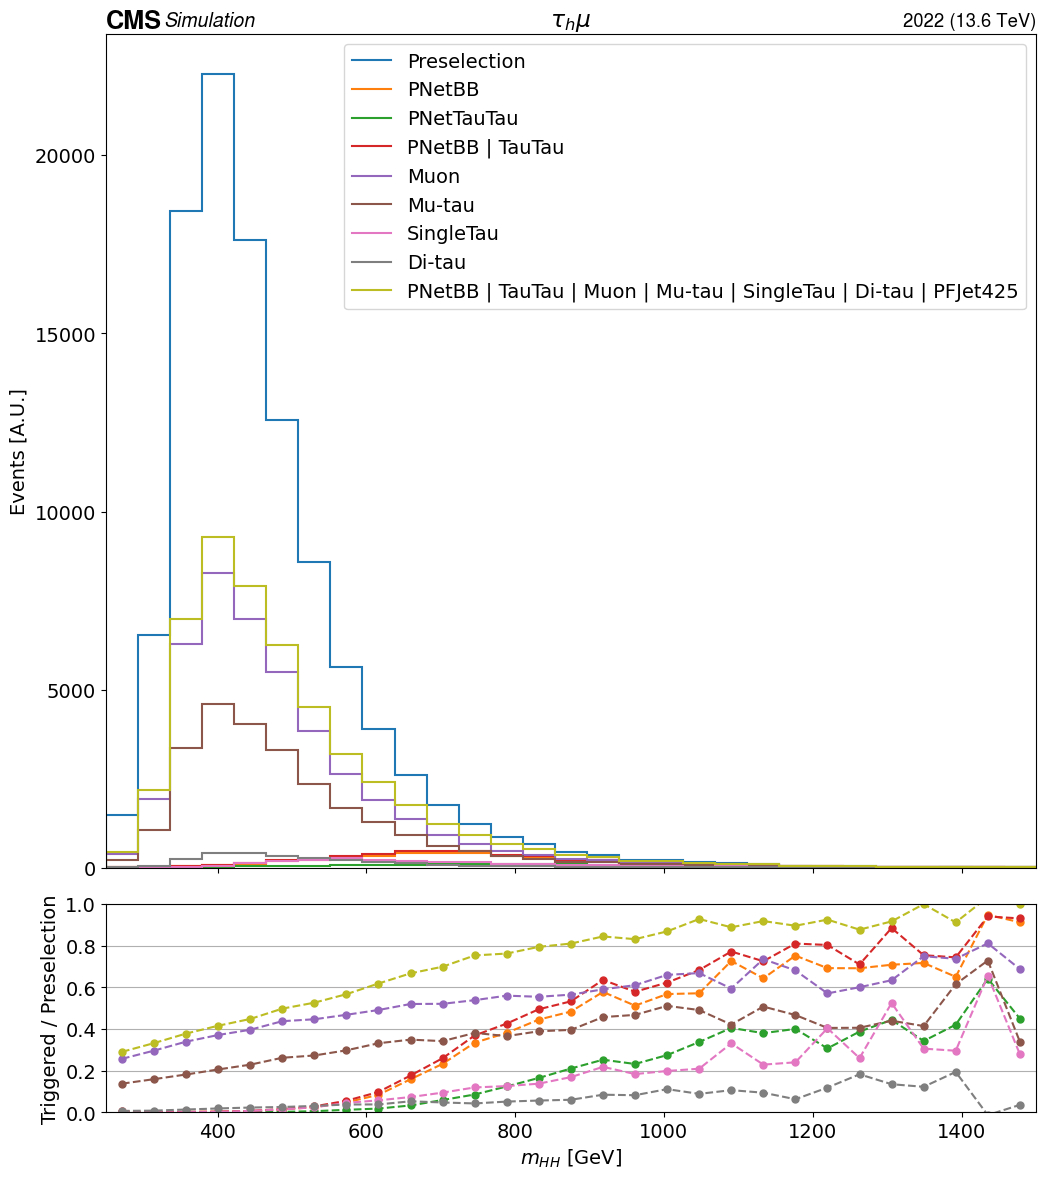

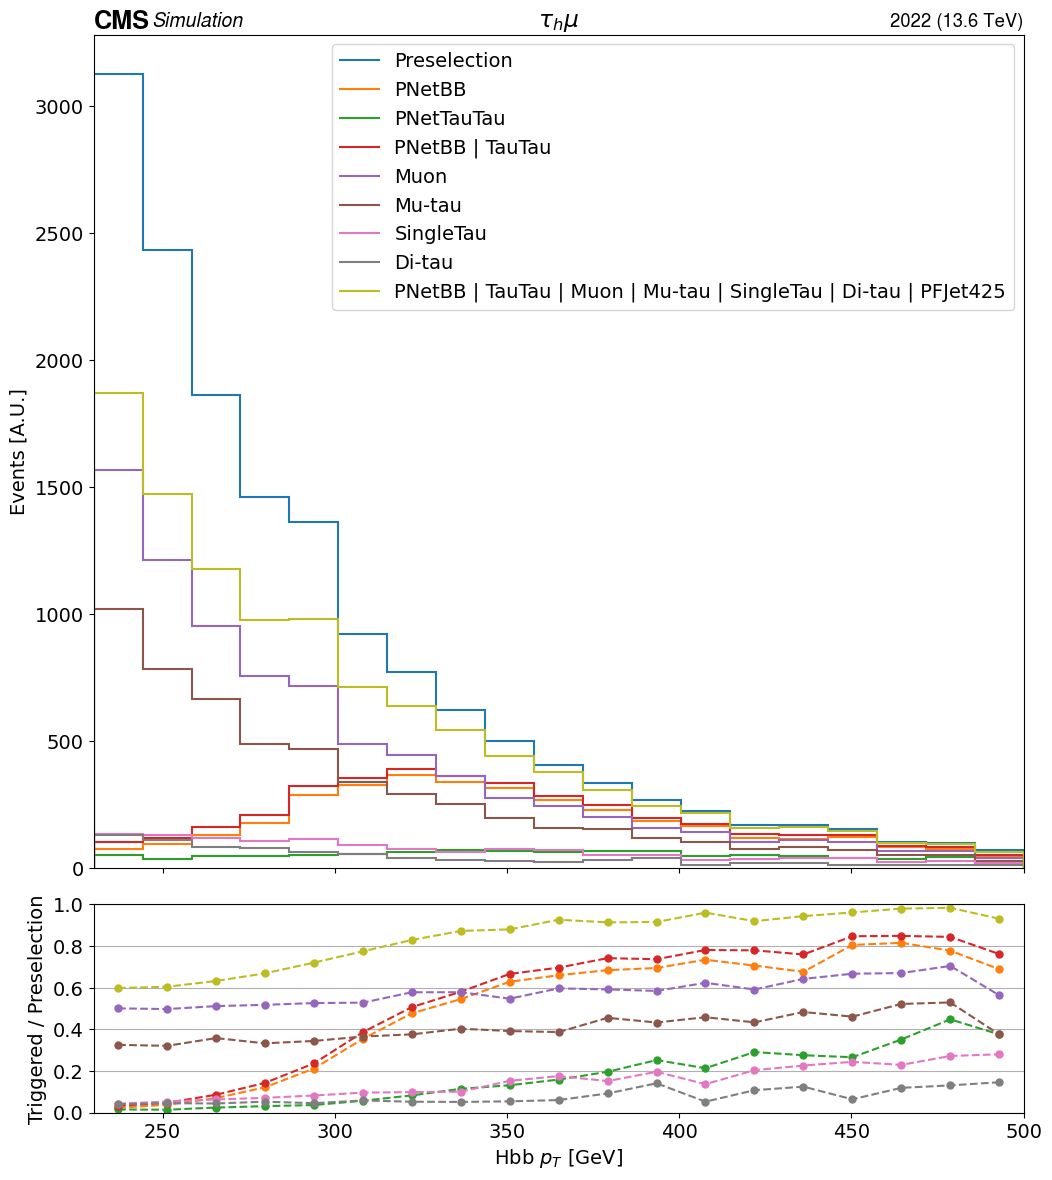

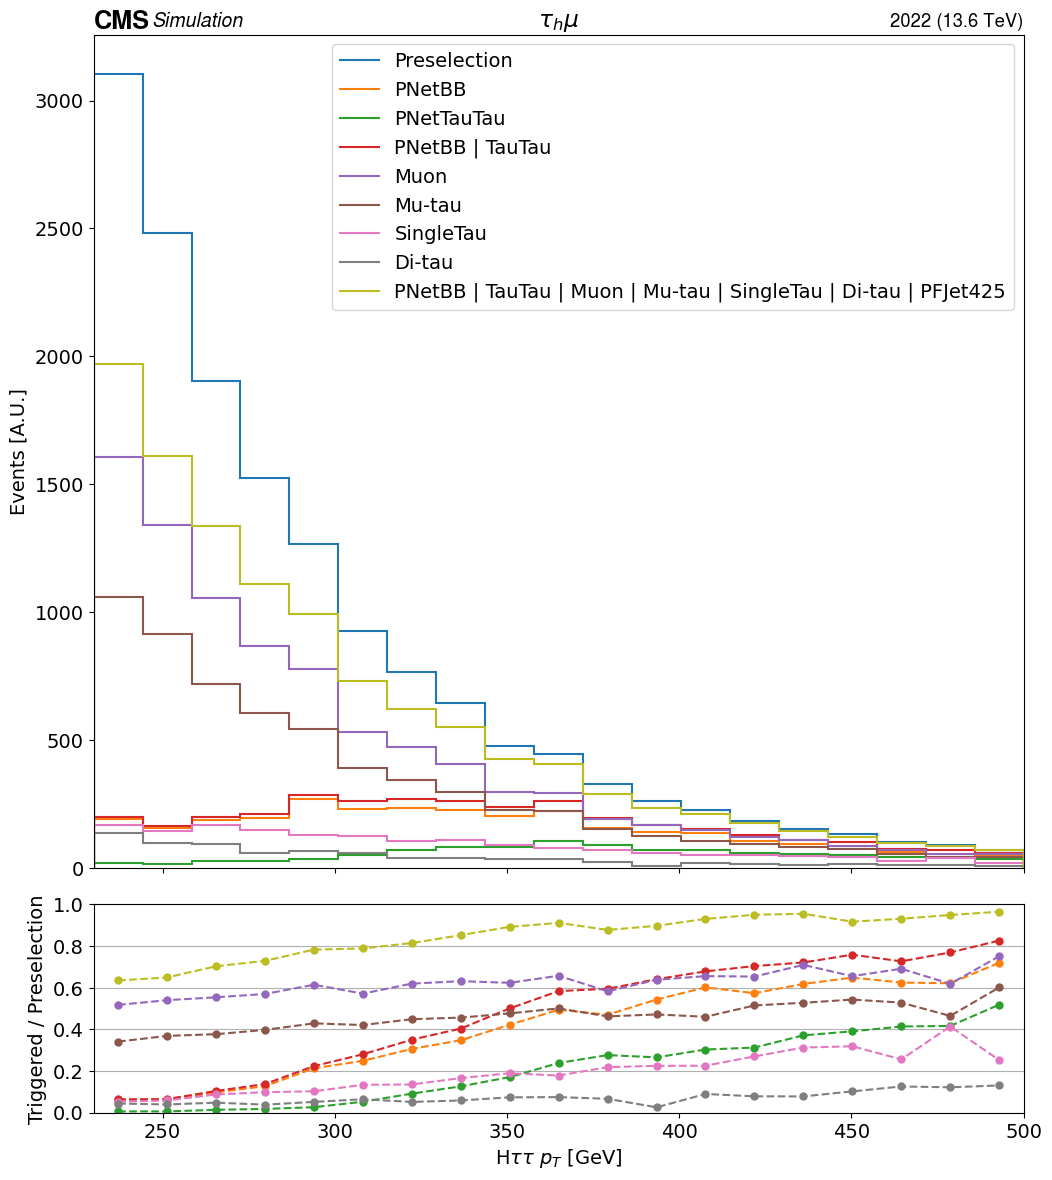

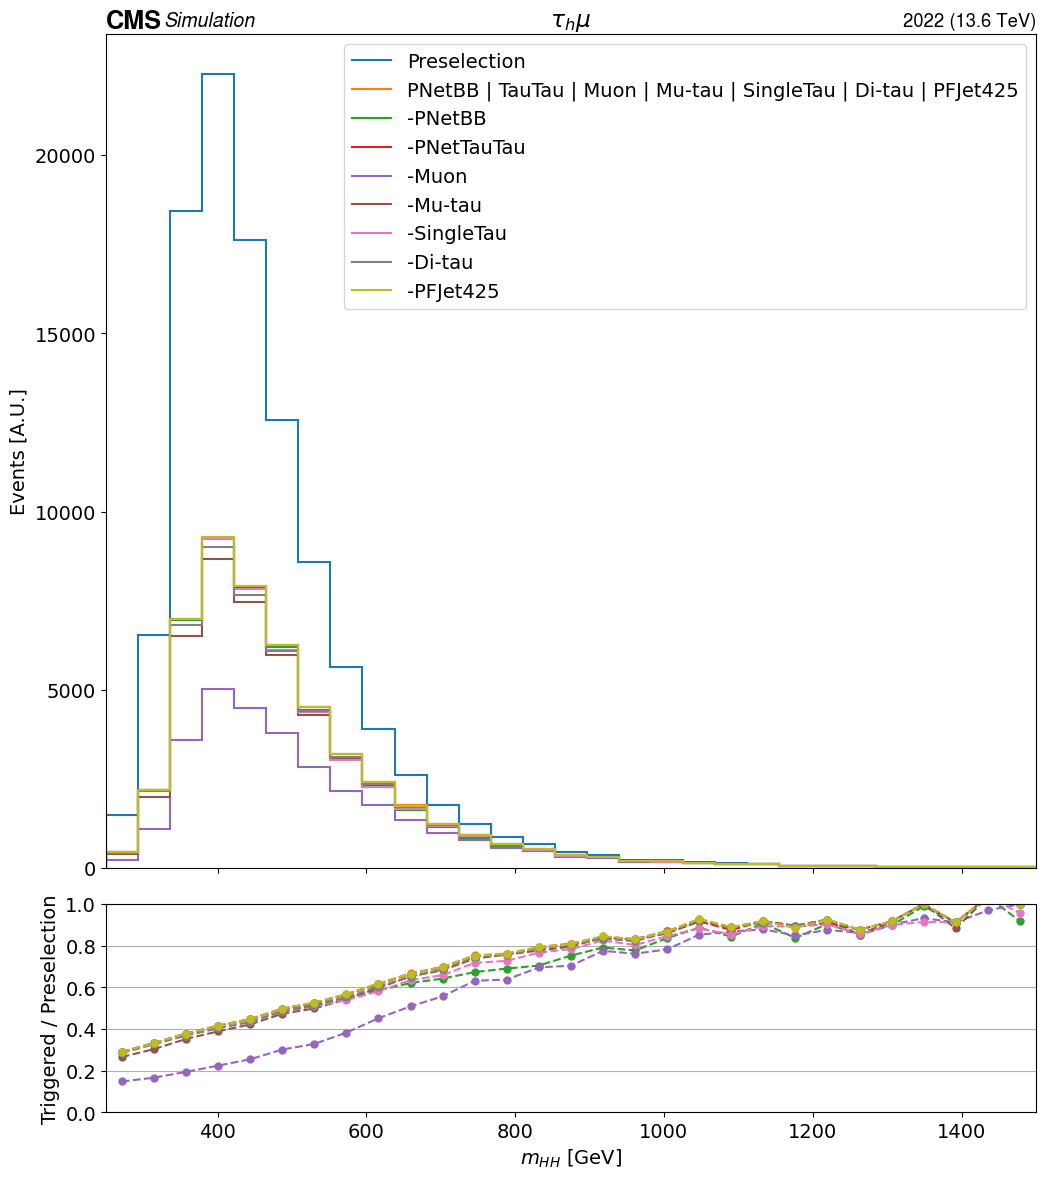

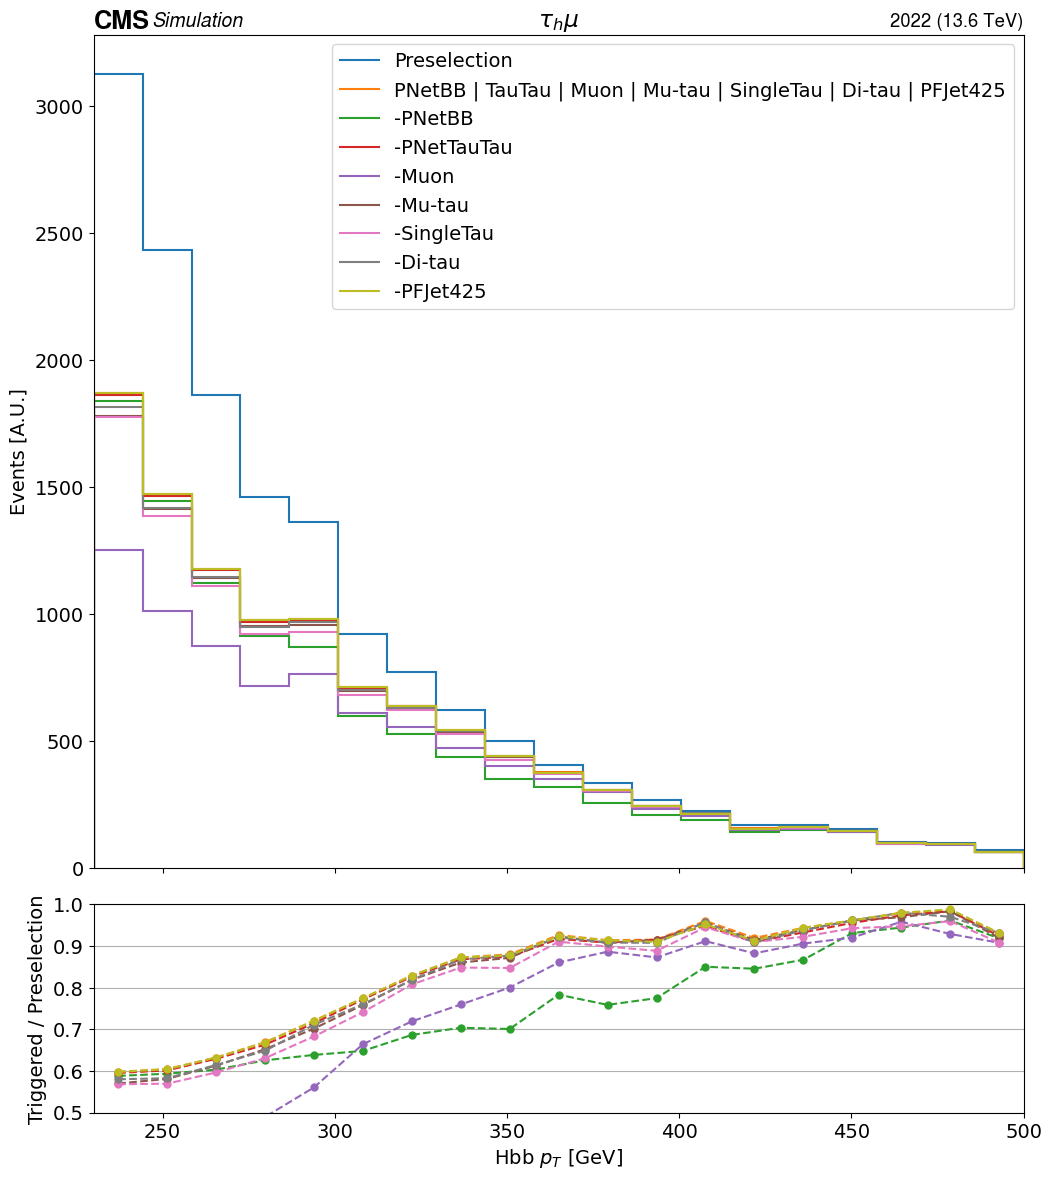

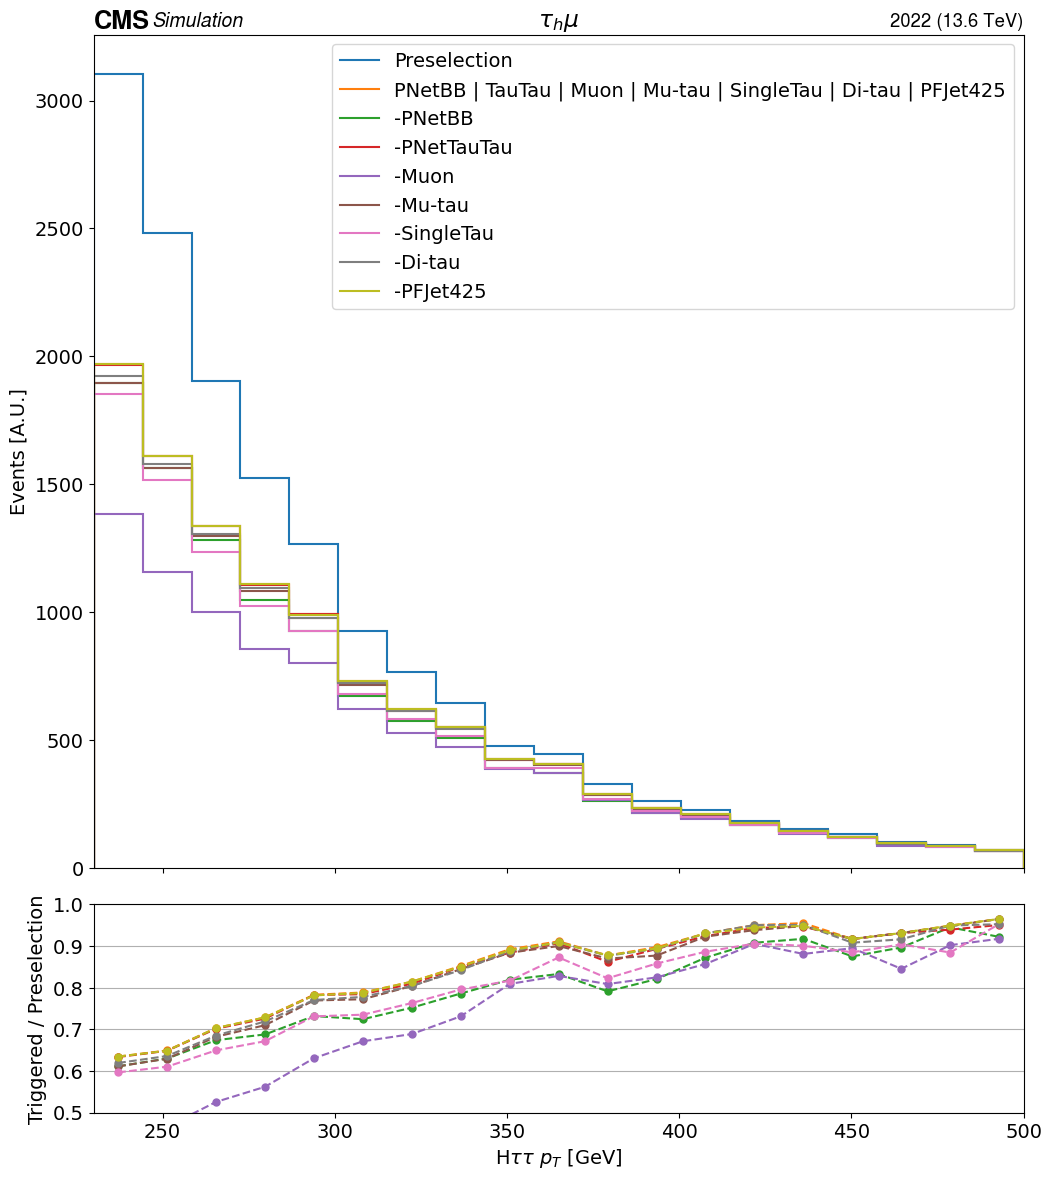

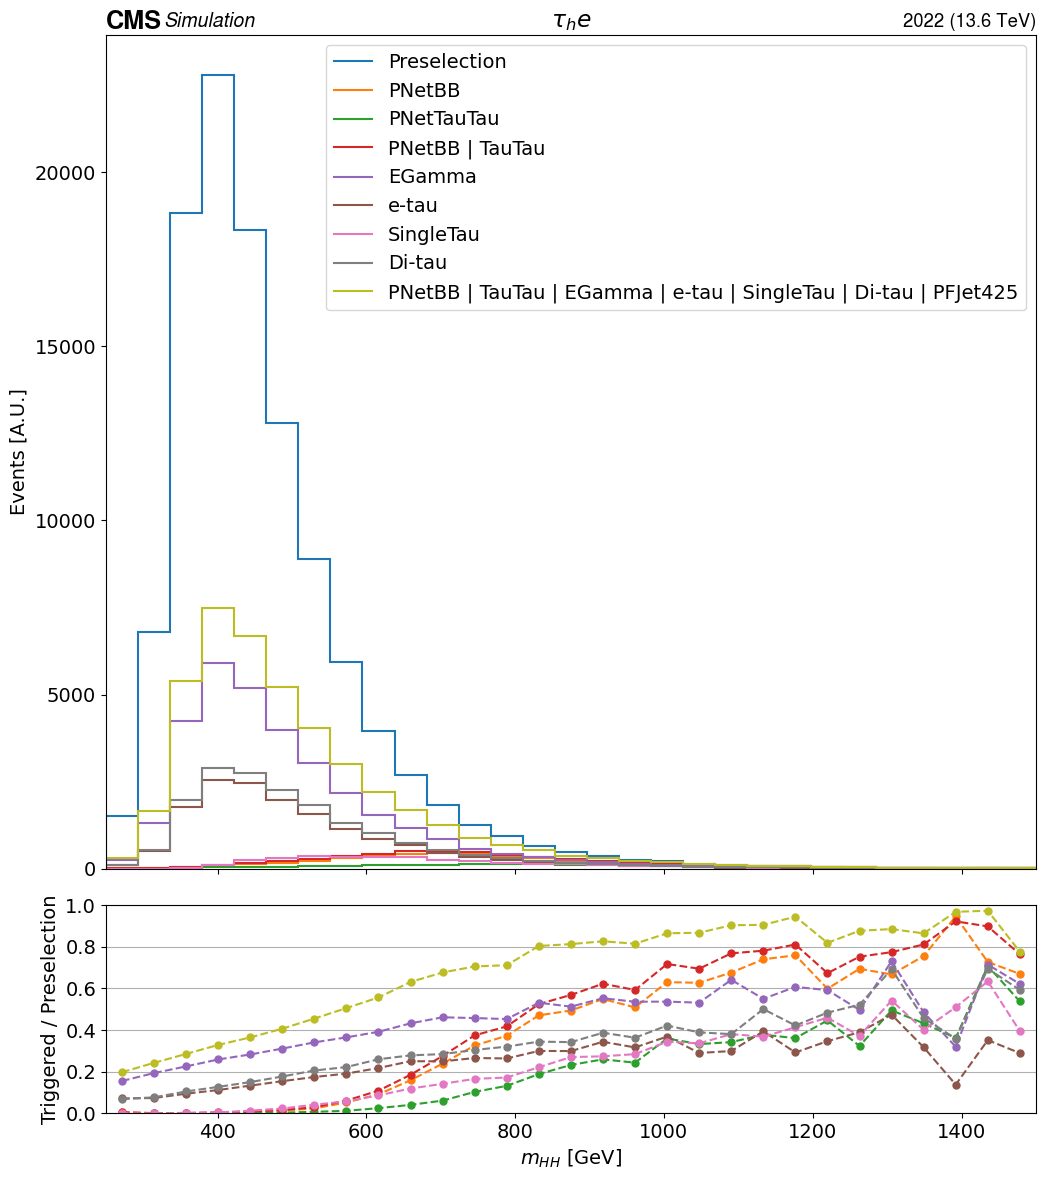

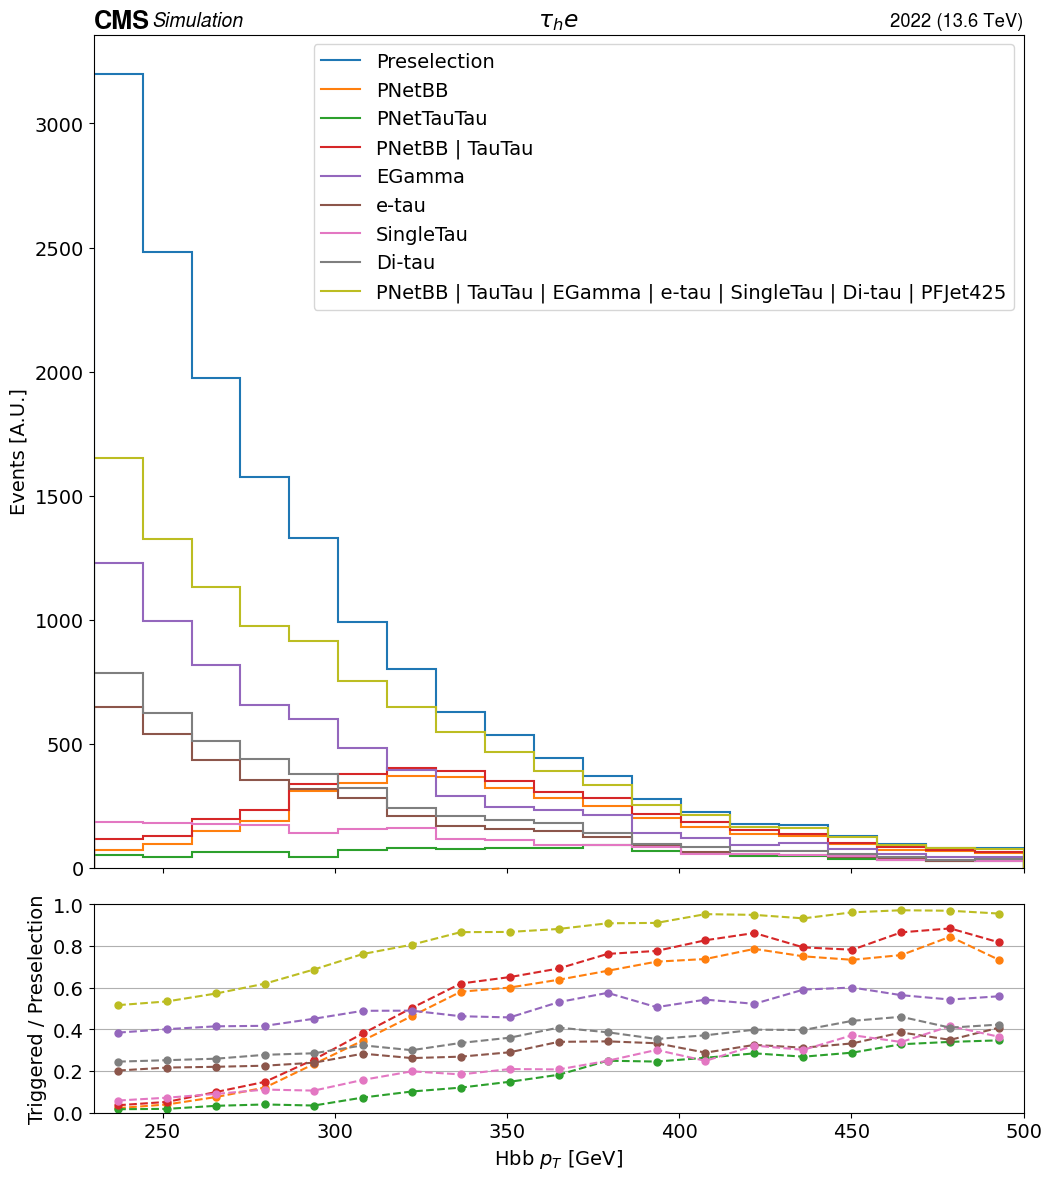

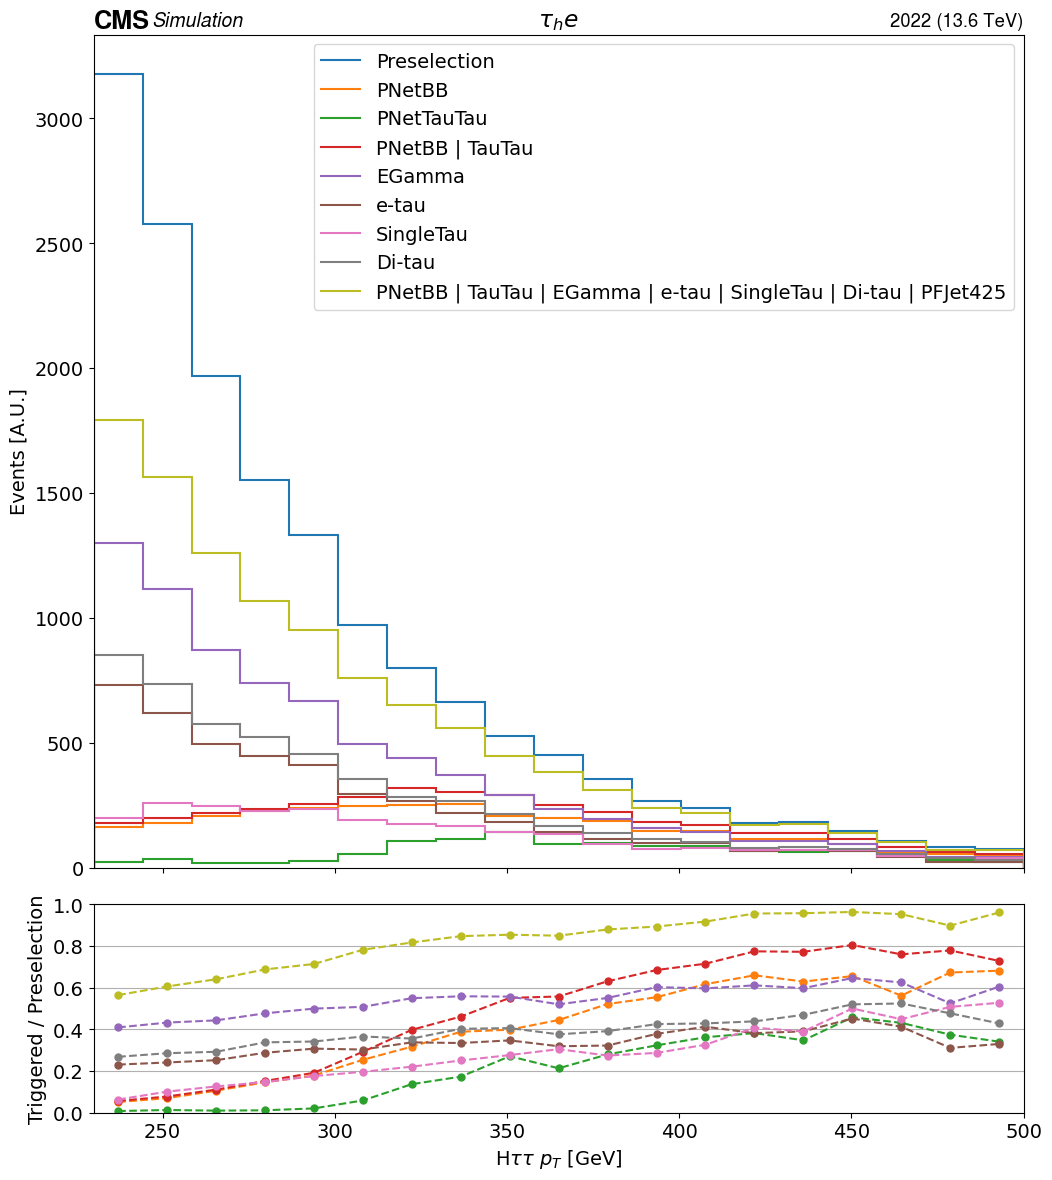

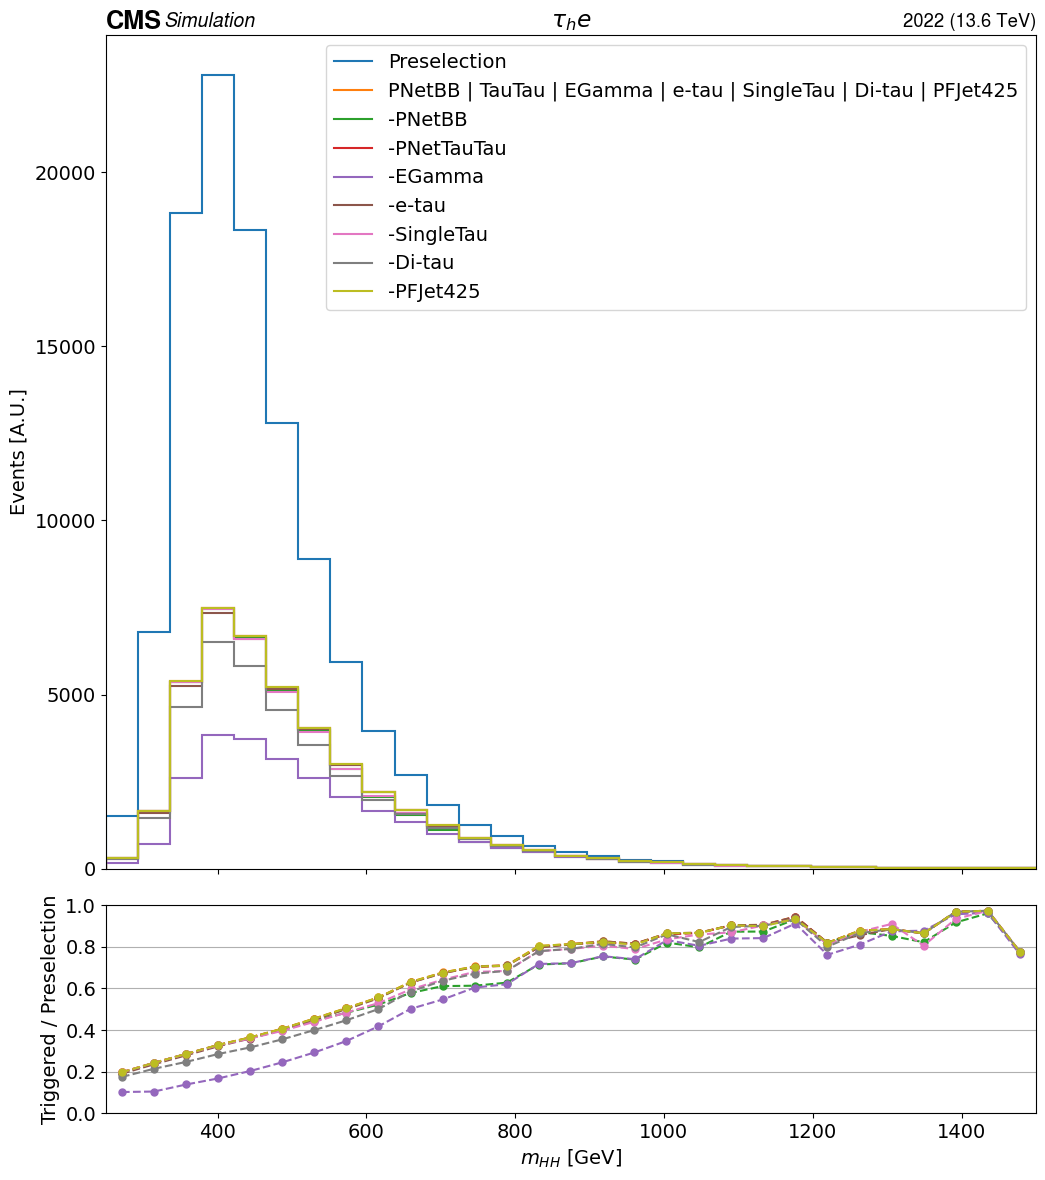

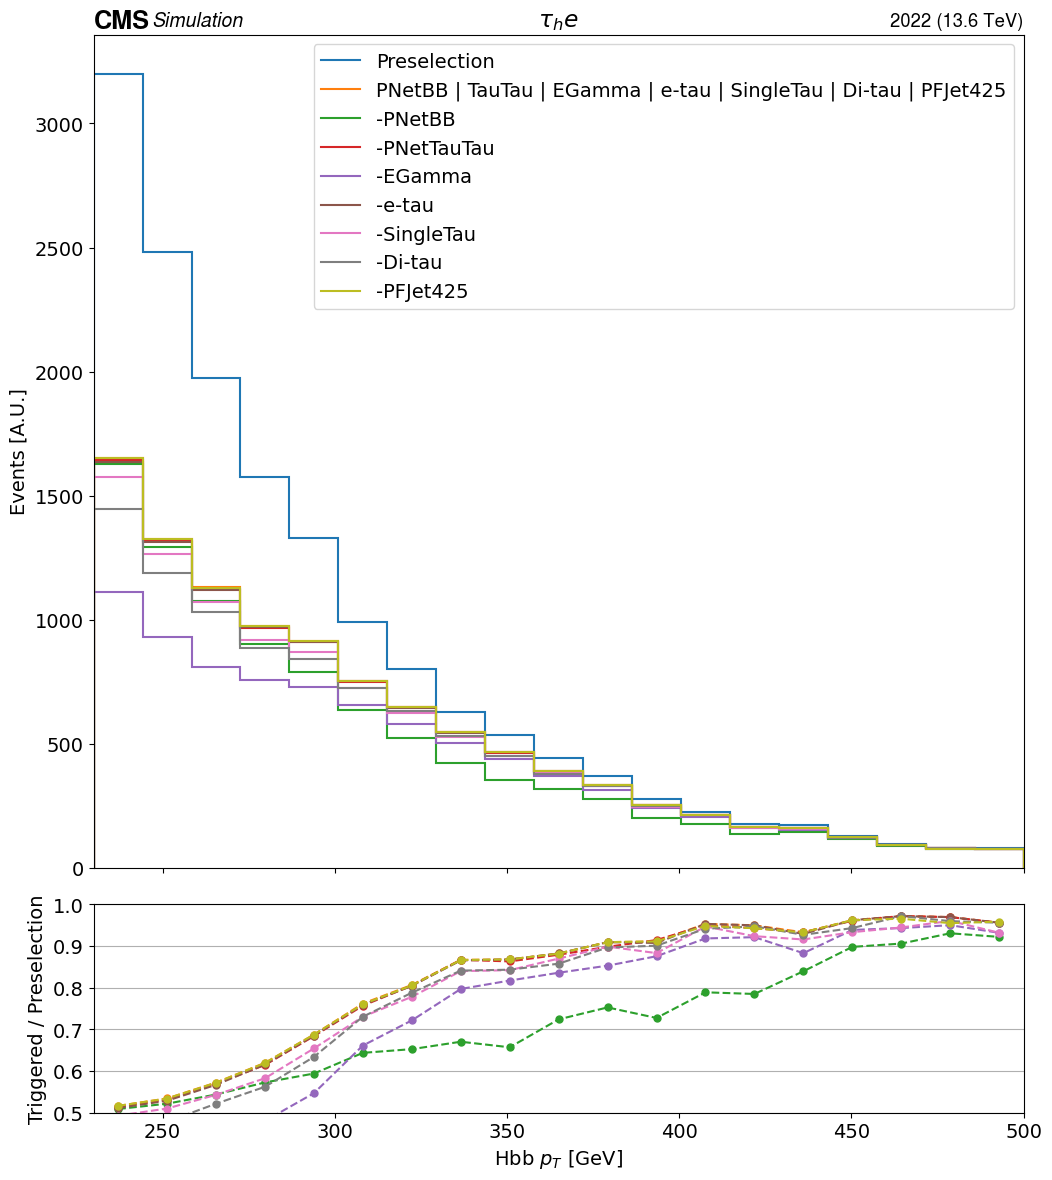

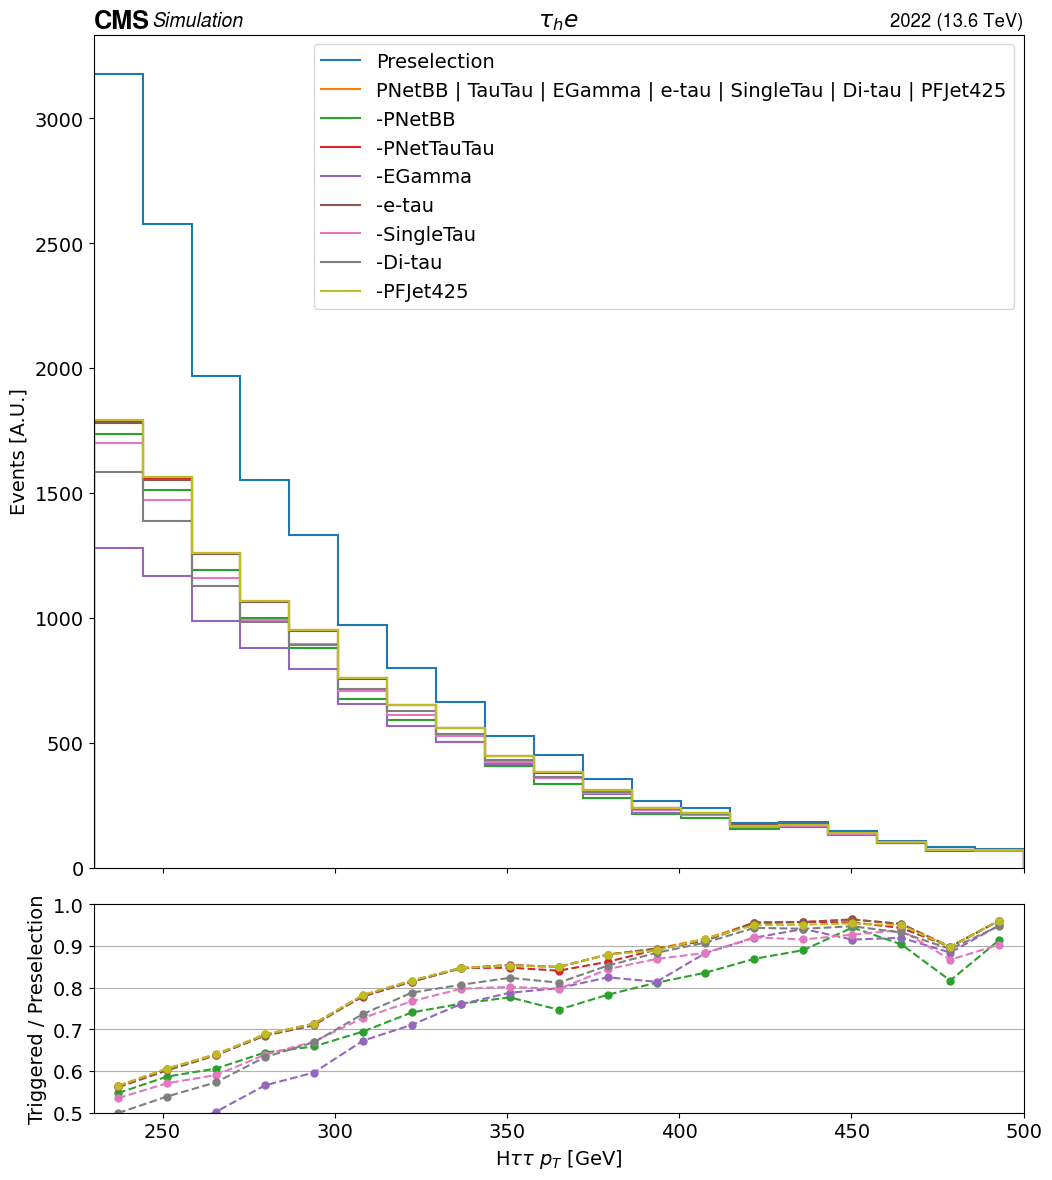

In [44]:
plt.rcParams.update({"font.size": 14})

plot_vars = [
    (mhh, "mhh", r"$m_{HH}$ [GeV]", np.linspace(250, 1500, 30)),
    (hbbpt, "hbbpt", r"Hbb $p_{T}$ [GeV]", np.linspace(230, 500, 20)),
    (httpt, "httpt", r"H$\tau\tau$ $p_{T}$ [GeV]", np.linspace(230, 500, 20)),
]

for cat, vals in triggers_dict.items():
    for kinvar, kinname, kinlabel, bins in plot_vars:
        (mask, label, triggers) = vals.values()

        fig, (ax, rax) = plt.subplots(
            2, 1, figsize=(12, 14), gridspec_kw=dict(height_ratios=[4, 1], hspace=0.07), sharex=True
        )

        hists = {"Preselection": np.histogram(kinvar[mask], bins=bins, weights=weights[mask])}
        ratios = {}

        hep.histplot(
            hists["Preselection"],
            yerr=False,
            label="Preselection",
            ax=ax,
        )

        colours = plt.cm.tab10.colors[1:]

        for key, c in zip(triggers.keys(), colours):
            # print(key)
            hists[key] = np.histogram(
                kinvar[mask & triggers[key]], bins=bins, weights=weights[mask & triggers[key]]
            )
            ratios[key] = hists[key][0] / hists["Preselection"][0]

            hep.histplot(
                hists[key],
                yerr=False,
                label=key,
                ax=ax,
                color=c,
            )

            hep.histplot(
                (ratios[key], bins),
                yerr=False,
                label=key,
                ax=rax,
                histtype="errorbar",
                color=c,
                # markersize=20,
                linestyle="--",
                # markeredgewidth=3,
                # fillstyle='none',
            )

        ax.set_ylabel("Events [A.U.]")
        ax.legend()
        ax.set_title(label)
        ax.set_xlim(bins[0], bins[-1])
        ax.set_ylim(0)

        # rax.legend()
        rax.grid(axis="y")
        rax.set_xlabel(kinlabel)
        rax.set_ylabel("Triggered / Preselection")

        ylims = [0.5, 1] if (cat.endswith("minus") and kinname != "mhh") else [0, 1]
        rax.set_ylim(ylims)

        hep.cms.label(ax=ax, data=False, year=2022, com="13.6")

        plt.savefig(plot_dir / f"{kinname}_{cat}.pdf", bbox_inches="tight")
        plt.show()

In [45]:
plt.rcParams.update({"font.size": 14})

plot_vars = [
    (mhh, "mhh", r"$m_{HH}$ [GeV]", np.linspace(250, 1500, 30)),
    (hbbpt, "hbbpt", r"Hbb $p_{T}$ [GeV]", np.linspace(230, 500, 20)),
    (httpt, "httpt", r"H$\tau\tau$ $p_{T}$ [GeV]", np.linspace(230, 500, 20)),
]

for cat, vals in triggers_dict.items():
    print(cat)


tauhmu
tauhmu_minus
tauhe
tauhe_minus


In [46]:
weights

0         0.934380
1         1.035074
2        -1.048243
3         0.122868
4         0.130059
            ...   
854037    0.605246
854038    1.062044
854039    1.073157
854040    0.130059
854041    0.683481
Name: 0, Length: 854042, dtype: float64

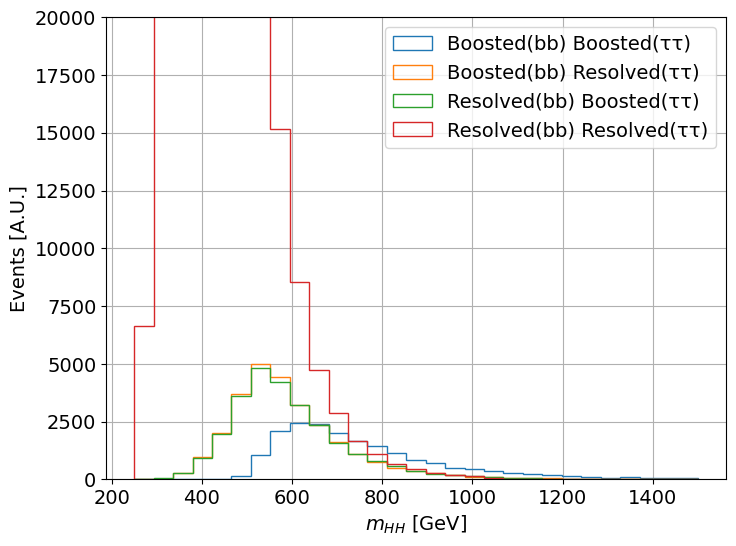

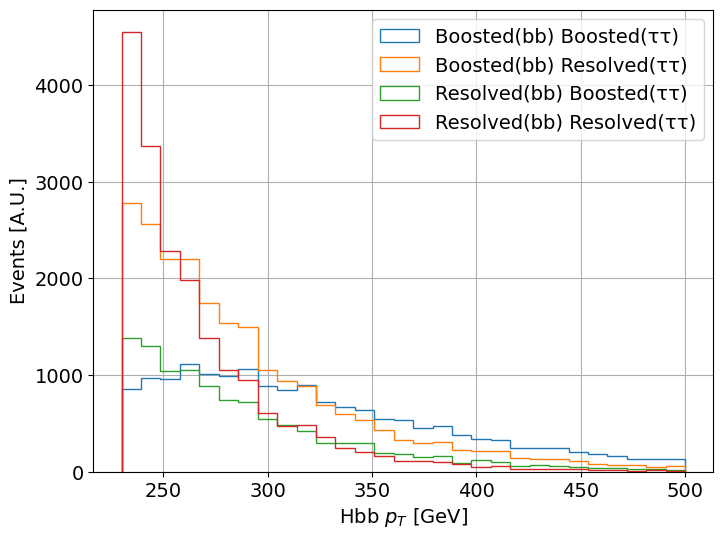

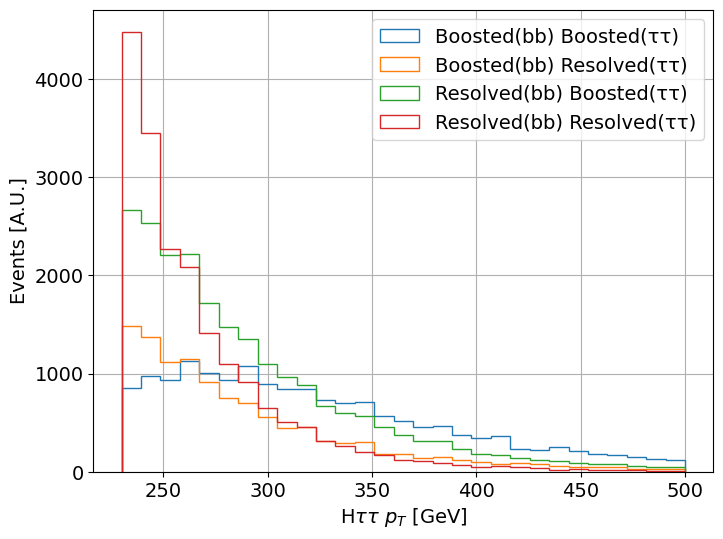

In [47]:
deltaR_threshold = 1.1


deltaR_bb = np.sqrt((df[('GenbbEta', 0)] - df[('GenbbEta', 1)])**2 +
                     (df[('GenbbPhi', 0)] - df[('GenbbPhi', 1)])**2)

deltaR_tau = np.sqrt((df[('GenTauEta', 0)] - df[('GenTauEta', 1)])**2 +
                      (df[('GenTauPhi', 0)] - df[('GenTauPhi', 1)])**2)


bb_boosted, bb_resolved = deltaR_bb < deltaR_threshold, deltaR_bb >= deltaR_threshold
tau_boosted, tau_resolved = deltaR_tau < deltaR_threshold, deltaR_tau >= deltaR_threshold

# We can add condtiioon for high momentum here for the higgs to check if Boosted higgs
# is decaying to the corresponding particle or not. But wat is the threshold momentum
# should be chosen for this cases?

categories = {
    "Boosted(bb) Boosted(ττ)": bb_boosted & tau_boosted,
    "Boosted(bb) Resolved(ττ)": bb_boosted & tau_resolved,
    "Resolved(bb) Boosted(ττ)": bb_resolved & tau_boosted,
    "Resolved(bb) Resolved(ττ)": bb_resolved & tau_resolved,
    # "At least one boosted": (bb_boosted & tau_resolved) | (bb_resolved & tau_boosted) | (bb_boosted & tau_boosted),
}

plot_vars = [
    (mhh, r"$m_{HH}$ [GeV]", np.linspace(250, 1500, 30), (0, 20000)),
    (hbbpt, r"Hbb $p_{T}$ [GeV]", np.linspace(230, 500, 30), None),
    (httpt, r"H$\tau\tau$ $p_{T}$ [GeV]", np.linspace(230, 500, 30), None),
]


for var, xlabel, bins, ylim in plot_vars:
    fig, ax = plt.subplots(figsize=(8, 6))
    
    for label, mask in categories.items():
        plt.hist(var[mask], bins=bins, weights=weights[mask],
                 histtype="step", label=label)

    plt.xlabel(xlabel)
    plt.ylabel("Events [A.U.]")
    plt.legend()
    plt.grid(True)

    # plt.yscale("log")
    plt.ylim(ylim)

    plt.show()

In [48]:
weights[bb_boosted & tau_boosted].sum()

18840.14743641338

In [49]:
np.sum(bb_boosted & tau_boosted)

38165

In [ ]:
# We can also look for resolved tautau going to hadrons, leptons, electron and all those stuffs

In [51]:
N_gen = weights.sum()  # Sum of event weights
N_boosted_bb_boosted_tau = weights[bb_boosted & tau_boosted].sum()
N_boosted_bb_resolved_tau = weights[bb_boosted & tau_resolved].sum()
N_resolved_bb_boosted_tau = weights[bb_resolved & tau_boosted].sum()
N_resolved_bb_resolved_tau = weights[bb_resolved & tau_resolved].sum()

epsilon_boosted_bb_boosted_tau = N_boosted_bb_boosted_tau / N_gen
epsilon_boosted_bb_resolved_tau = N_boosted_bb_resolved_tau / N_gen
epsilon_resolved_bb_boosted_tau = N_resolved_bb_boosted_tau / N_gen
epsilon_resolved_bb_resolved_tau = N_resolved_bb_resolved_tau / N_gen

BR = 7.3/100 # Branching ratio HH->bbtautau
sigma_HH = 34 * BR  # HH cross-section in fb
L_run3 = 34.65 # 2022  # Expected luminosity in fb^-1
# Multiply by the BR

yield_boosted_bb_boosted_tau = sigma_HH * L_run3 * epsilon_boosted_bb_boosted_tau
yield_boosted_bb_resolved_tau = sigma_HH * L_run3 * epsilon_boosted_bb_resolved_tau
yield_resolved_bb_boosted_tau = sigma_HH * L_run3 * epsilon_resolved_bb_boosted_tau
yield_resolved_bb_resolved_tau = sigma_HH * L_run3 * epsilon_resolved_bb_resolved_tau

print(f"Expected Signal Yield (Boosted(bb) Boosted(ττ)): {yield_boosted_bb_boosted_tau:.3f}")
print(f"Expected Signal Yield (Boosted(bb) Resolved(ττ)): {yield_boosted_bb_resolved_tau:.3f}")
print(f"Expected Signal Yield (Resolved(bb) Boosted(ττ)): {yield_resolved_bb_boosted_tau:.3f}")
print(f"Expected Signal Yield (Resolved(bb) Resolved(ττ)): {yield_resolved_bb_resolved_tau:.3f}")

Expected Signal Yield (Boosted(bb) Boosted(ττ)): 3.378
Expected Signal Yield (Boosted(bb) Resolved(ττ)): 4.922
Expected Signal Yield (Resolved(bb) Boosted(ττ)): 4.806
Expected Signal Yield (Resolved(bb) Resolved(ττ)): 72.894


In [ ]:
# Check 

In [ ]:
def delta_r(eta1, phi1, eta2, phi2):
    """Delta_R with stable, wrapped Delta_phi."""
    dphi = np.mod(phi1 - phi2 + np.pi, 2*np.pi) - np.pi # making \phi \in [-pi, +pi]
    return np.hypot(eta1 - eta2, dphi)

def match_mask(h_eta, h_phi, j_eta, j_phi, j_pt,
               dr_max, pt_min, n_needed):
    """
    Does *at least* n_needed jets satisfy Delta_R < dr_max and pT > pt_min ?
    Works event-wise on N X n_needed arrays (N events, n_needed jets).
    """
    dR = delta_r(h_eta[:, None], h_phi[:, None],
                 j_eta,          j_phi)
    cond = (dR < dr_max) & (j_pt > pt_min) # Should we also verify with the particles id?
    return (cond.sum(axis=1) >= n_needed)  # First tau should be checked with any of the jets and same for the ssecond tau


In [56]:

# Check the vector library

# pull the columns out in numpy (way easier!!)
# TODO: Clean it up later with just pd implemenation 
H_eta  = df[('GenHiggsEta', 0)].to_numpy(), df[('GenHiggsEta', 1)].to_numpy()
H_phi  = df[('GenHiggsPhi', 0)].to_numpy(), df[('GenHiggsPhi', 1)].to_numpy()
H_pt   = df[('GenHiggsPt',  0)].to_numpy(), df[('GenHiggsPt',  1)].to_numpy()
H_ch   = df[('GenHiggsChildren', 0)].to_numpy(), \
         df[('GenHiggsChildren', 1)].to_numpy()


In [ ]:
# Three AK8 jets
ak8_eta = np.vstack([df[('ak8FatJetEta', i)].to_numpy()
                     for i in (0,1,2)]).T       # shape (N,3)
ak8_phi = np.vstack([df[('ak8FatJetPhi', i)].to_numpy()
                     for i in (0,1,2)]).T
ak8_pt  = np.vstack([df[('ak8FatJetPt',  i)].to_numpy()
                     for i in (0,1,2)]).T

# Four AK4 jets
ak4_eta = np.vstack([df[('ak4JetEta',    i)].to_numpy()
                     for i in (0,1,2,3)]).T     # shape (N,4)
ak4_phi = np.vstack([df[('ak4JetPhi',    i)].to_numpy()
                     for i in (0,1,2,3)]).T
ak4_pt  = np.vstack([df[('ak4JetPt',     i)].to_numpy()
                     for i in (0,1,2,3)]).T

# replace NaNs (empty jet slots) with random values so they never match
ak8_eta  = np.nan_to_num(ak8_eta,  nan= 99.)
ak8_phi  = np.nan_to_num(ak8_phi,  nan= 99.)
ak8_pt   = np.nan_to_num(ak8_pt,   nan= -1.)
ak4_eta  = np.nan_to_num(ak4_eta,  nan= 99.)
ak4_phi  = np.nan_to_num(ak4_phi,  nan= 99.)
ak4_pt   = np.nan_to_num(ak4_pt,   nan= -1.)

In [ ]:
# tau_2ak4 = match_mask(
#     np.choose(tauIdx, H_eta), np.choose(tauIdx, H_phi),
#     ak4_eta, ak4_phi, ak4_pt,
#     dr_ak4, pt4_min, 2
# )

array([1, 0, 0, ..., 1, 0, 1])

In [71]:
dr_ak8, dr_ak4 = 0.8, 0.4
pt8_min, pt4_min = 200., 20.

# 1. BOOSTED: We need two distinct AK8 jets, one per Higgs
match0 = match_mask(H_eta[0], H_phi[0],
                    ak8_eta, ak8_phi, ak8_pt,
                    dr_ak8, pt8_min, 1)
match1 = match_mask(H_eta[1], H_phi[1],
                    ak8_eta, ak8_phi, ak8_pt,
                    dr_ak8, pt8_min, 1)
boosted_pass = match0 & match1      # boolean (N,)

# 2. SEMI‑RESOLVED:
# Whch Higgs is bb (child == 5) and TauTau (15)
is_bb   = (np.vstack(H_ch) == 5).T  # shape (N,2) bool
is_tau  = (np.vstack(H_ch) == 15).T 
bbIdx   = is_bb.argmax(axis=1)      # 0/1
tauIdx  = is_tau.argmax(axis=1)

#  AK8 for bb‑Higgs
bb_ak8  = ( (bbIdx==0) & match0 ) | ( (bbIdx==1) & match1)

# >=2 AK4 for TauTau‑Higgs


ak4_match0 = match_mask(
    H_eta[0], H_phi[0],
    ak4_eta, ak4_phi, ak4_pt,
    dr_ak4, pt4_min, 2
)

ak4_match1 = match_mask(
    H_eta[1], H_phi[1],
    ak4_eta, ak4_phi, ak4_pt,
    dr_ak4, pt4_min, 2
)

_2_Tau_ak4 = (
    ((tauIdx==0) & ak4_match0 )
    | ((tauIdx==1) & ak4_match1 )
) 

tau_2ak4 = _2_Tau_ak4

semi_pass = bb_ak8 & tau_2ak4       # boolean (N,)


In [ ]:
tau_vec = utils.make_vector(df, name='GenTau')
tau_eta = tau_vec.eta  # shape (N, 2) 
tau_phi = tau_vec.phi

def tau_all_matched(tau_eta, tau_phi,
                    j_eta, j_phi, j_pt,
                    dr_max, pt_min, n_needed):
    dR = delta_r(tau_eta[..., None], tau_phi[..., None],
                 j_eta[:, None, :], j_phi[:, None, :])
    cond = (dR < dr_max) & (j_pt[:, None, :] > pt_min)
    return cond.any(axis=2).all(axis=1)  # 2 taus matched

tau_2ak4 = tau_all_matched(tau_eta, tau_phi,
                           ak4_eta, ak4_phi, ak4_pt,
                           dr_ak4, pt4_min)

semi_pass = bb_ak8 & tau_2ak4

In [77]:
# efficiency vs variable 
def efficiency_vs(var, sel_mask, bins):
    counts_total, _   = np.histogram(var, bins=bins)
    counts_pass,  _   = np.histogram(var[sel_mask], bins=bins)
    with np.errstate(divide='ignore', invalid='ignore'):
        eff = counts_pass / counts_total
    eff[counts_total == 0] = np.nan
    return eff, counts_total, counts_pass


In [78]:
# (VOI) Variables Of Interest
mhh   = (utils.make_vector(df, name='GenHiggs')[:,0] +
         utils.make_vector(df, name='GenHiggs')[:,1]).mass
hbbpt = np.where(bbIdx==0, H_pt[0], H_pt[1])   # pT of Hbb
httpt = np.where(tauIdx==0, H_pt[0], H_pt[1])  # pT of Htt

bin_cfg = {
    'mhh'   : np.linspace(250,1500,50),
    'hbbpt' : np.linspace(0,800,50),
    'httpt' : np.linspace(0,800,50),
}

xlabels_cfg = {
    'mhh'   : r'$m_{HH}$',
    'hbbpt' : r'$pT (H_{bb})$',
    'httpt' : r'$pT (H_{\tau\tau})$',
}

results = {}
for name, arr in zip(('mhh','hbbpt','httpt'), (mhh,hbbpt,httpt)):
    eff_boost, tot, pas = efficiency_vs(arr, boosted_pass, bin_cfg[name])
    eff_semi , _,   _   = efficiency_vs(arr, semi_pass, bin_cfg[name])
    results[name] = dict(
        bins = bin_cfg[name],
        eff_boosted = eff_boost,
        eff_semi    = eff_semi,
        total       = tot,
    )


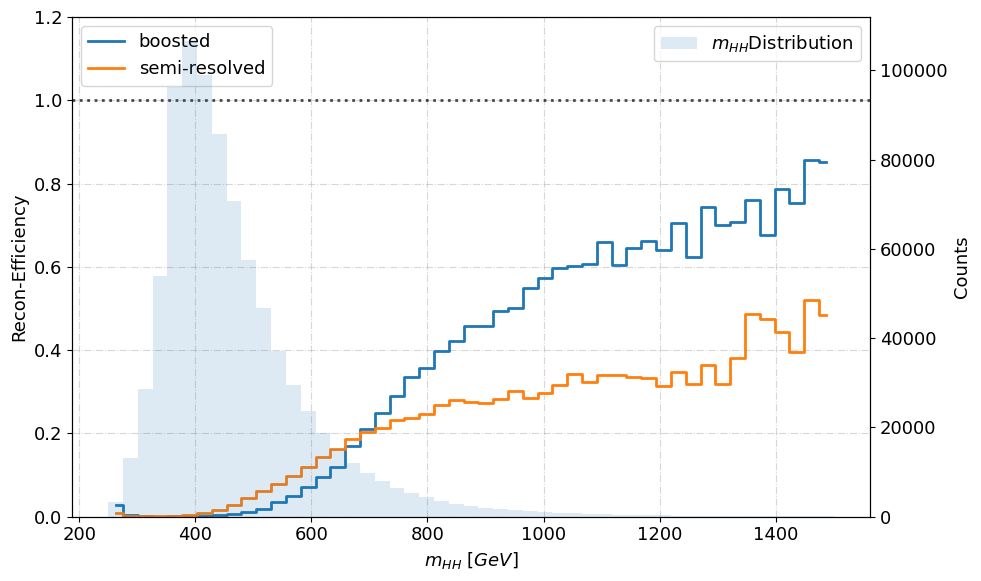

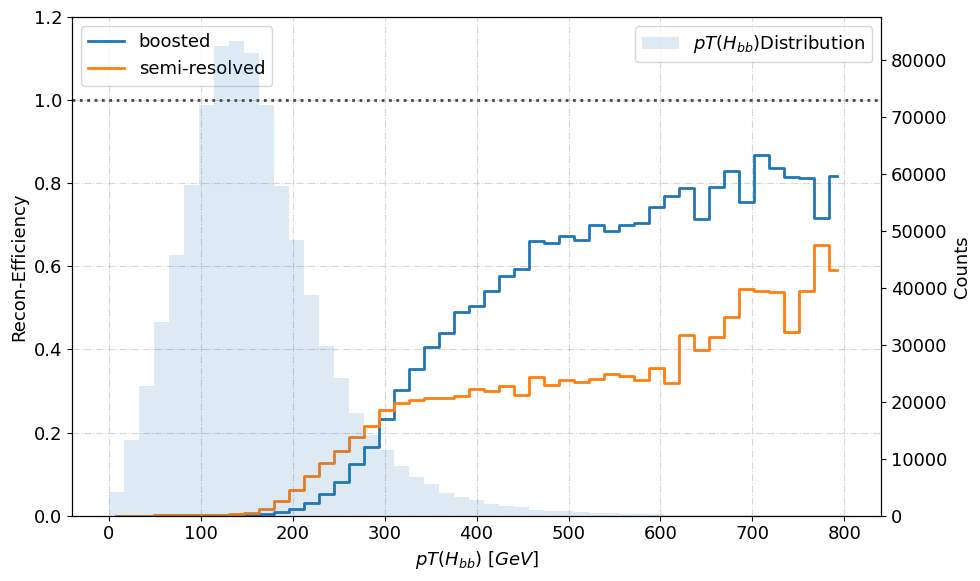

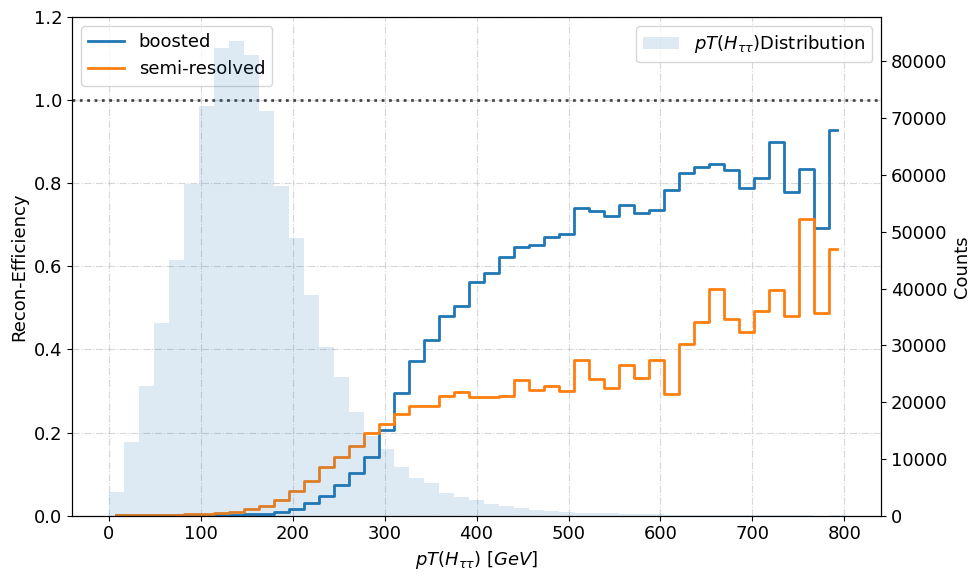

In [79]:
plt.rcParams.update({'font.size':13})

for vname,res in results.items():
    bins      = res['bins']
    bc        = .5*(bins[1:]+bins[:-1])      
    e_boosted = res['eff_boosted']
    e_semi    = res['eff_semi']
    tot       = res['total']

    # Add weights in the histograms
    fig,ax = plt.subplots(figsize=(10,6))
    ax.step(bc,e_boosted,where='mid',lw=2,
            label='boosted') 
    ax.step(bc,e_semi   ,where='mid',lw=2,
            label='semi‑resolved')
    ax.set(xlabel=xlabels_cfg[vname] + r' [$GeV]$',ylabel='Recon-Efficiency',
           ylim=(0,1.2))

    ax.axhline(y=1, linestyle=':', color='black',
           alpha=0.7, linewidth=2)


    ax.grid(ls='-.',alpha=.5)

    ax2 = ax.twinx()
    ax2.bar(bc,tot,width=np.diff(bins),alpha=.15,
            label=xlabels_cfg[vname] + 'Distribution')
    ax2.set_ylabel('Counts') # May be add weights in here

    ax.legend(loc='upper left')
    ax2.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

    


In [50]:
categories = {
    "Boosted(bb) Boosted(ττ)": bb_boosted & tau_boosted,
    "Boosted(bb) Resolved(ττ)": bb_boosted & tau_resolved,
    "Resolved(bb) Boosted(ττ)": bb_resolved & tau_boosted,
    "Resolved(bb) Resolved(ττ)": bb_resolved & tau_resolved,
    # "At least one boosted": (bb_boosted & tau_resolved) | (bb_resolved & tau_boosted) | (bb_boosted & tau_boosted),
}

triggers_dict = {
    "Boosted(bb) Boosted(ττ)": {
        "mask": bb_boosted & tau_boosted,
        "label":"Boosted(bb) Boosted(ττ)",
        "triggers": {
            "PNetBB": pnetbb,
            "PNetTauTau": pnettt,
            "PNetBB | TauTau": pnet,
            "Muon": singlemuon,
            "Mu-tau": mutau,
            "SingleTau": singletau,
            "Di-tau": ditau,
            "PNetBB | TauTau | Muon | Mu-tau | SingleTau | Di-tau | PFJet425": pnet
            | singlemuon
            | mutau
            | singletau
            | ditau
            | pfjet,
        },
    },
    "Boosted(bb) Resolved(ττ)": {
        "mask":  bb_boosted & tau_resolved,
        "label": "Boosted(bb) Resolved(ττ)",
        "triggers": {
            "PNetBB | TauTau | Muon | Mu-tau | SingleTau | Di-tau | PFJet425": pnet
            | singlemuon
            | mutau
            | singletau
            | ditau
            | pfjet,
            "-PNetBB": pnettt | singlemuon | mutau | singletau | ditau | pfjet,
            "-PNetTauTau": pnetbb | singlemuon | mutau | singletau | ditau | pfjet,
            "-Muon": pnet | mutau | singletau | ditau | pfjet,
            "-Mu-tau": pnet | singlemuon | singletau | ditau | pfjet,
            "-SingleTau": pnet | singlemuon | mutau | ditau | pfjet,
            "-Di-tau": pnet | singlemuon | mutau | singletau | pfjet,
            "-PFJet425": pnet | singlemuon | mutau | singletau | ditau,
        },
    },
    "Resolved(bb) Boosted(ττ)": {
        "mask": bb_resolved & tau_boosted,
        "label": "Resolved(bb) Boosted(ττ)",
        "triggers": {
            "PNetBB": pnetbb,
            "PNetTauTau": pnettt,
            "PNetBB | TauTau": pnet,
            "EGamma": egamma,
            "e-tau": etau,
            "SingleTau": singletau,
            "Di-tau": ditau,
            "PNetBB | TauTau | EGamma | e-tau | SingleTau | Di-tau | PFJet425": pnet
            | egamma
            | etau
            | singletau
            | ditau
            | pfjet,
        },
    },
    "Resolved(bb) Resolved(ττ)": {
        "mask": bb_resolved & tau_resolved,
        "label": "Resolved(bb) Resolved(ττ)",
        "triggers": {
            "PNetBB | TauTau | EGamma | e-tau | SingleTau | Di-tau | PFJet425": pnet
            | egamma
            | etau
            | singletau
            | ditau
            | pfjet,
            "-PNetBB": pnettt | egamma | etau | singletau | ditau | pfjet,
            "-PNetTauTau": pnetbb | egamma | etau | singletau | ditau | pfjet,
            "-EGamma": pnet | etau | singletau | ditau | pfjet,
            "-e-tau": pnet | egamma | singletau | ditau | pfjet,
            "-SingleTau": pnet | egamma | etau | ditau | pfjet,
            "-Di-tau": pnet | egamma | etau | singletau | pfjet,
            "-PFJet425": pnet | egamma | etau | singletau | ditau,
        },
    },
}

In [51]:
categories = {
    "Boosted(bb) Boosted(ττ)": bb_boosted & tau_boosted,
    "Boosted(bb) Resolved(ττ)": bb_boosted & tau_resolved,
    "Resolved(bb) Boosted(ττ)": bb_resolved & tau_boosted,
    "Resolved(bb) Resolved(ττ)": bb_resolved & tau_resolved,
    # "At least one boosted": (bb_boosted & tau_resolved) | (bb_resolved & tau_boosted) | (bb_boosted & tau_boosted),
}

triggers_dict = {
    "Boosted(bb) Resolved(ττ)": {
        "mask":  bb_boosted & tau_resolved,
        "label": "Boosted(bb) Resolved(ττ)",
        "triggers": {
            "PNetBB | TauTau | Muon | Mu-tau | SingleTau | Di-tau | PFJet425": pnet
            | singlemuon
            | mutau
            | singletau
            | ditau
            | pfjet,
            "-PNetBB": pnettt | singlemuon | mutau | singletau | ditau | pfjet,
            "-PNetTauTau": pnetbb | singlemuon | mutau | singletau | ditau | pfjet,
            "-Muon": pnet | mutau | singletau | ditau | pfjet,
            "-Mu-tau": pnet | singlemuon | singletau | ditau | pfjet,
            "-SingleTau": pnet | singlemuon | mutau | ditau | pfjet,
            "-Di-tau": pnet | singlemuon | mutau | singletau | pfjet,
            "-PFJet425": pnet | singlemuon | mutau | singletau | ditau,
        },
    },
    "Resolved(bb) Boosted(ττ)": {
        "mask": bb_resolved & tau_boosted,
        "label": "Resolved(bb) Boosted(ττ)",
        "triggers": {
            "PNetBB": pnetbb,
            "PNetTauTau": pnettt,
            "PNetBB | TauTau": pnet,
            "EGamma": egamma,
            "e-tau": etau,
            "SingleTau": singletau,
            "Di-tau": ditau,
            "PNetBB | TauTau | EGamma | e-tau | SingleTau | Di-tau | PFJet425": pnet
            | egamma
            | etau
            | singletau
            | ditau
            | pfjet,
        },
    },
}

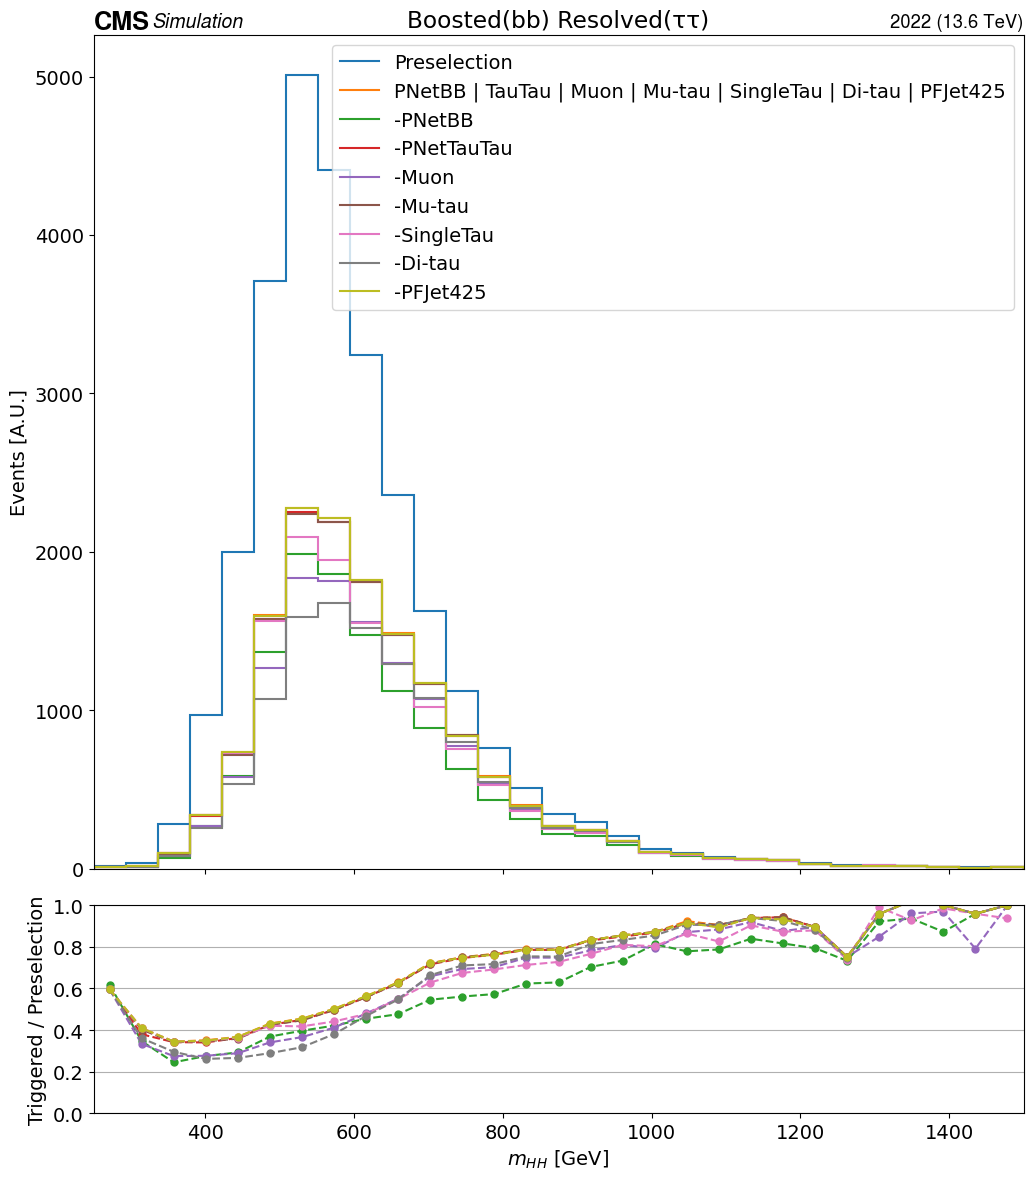

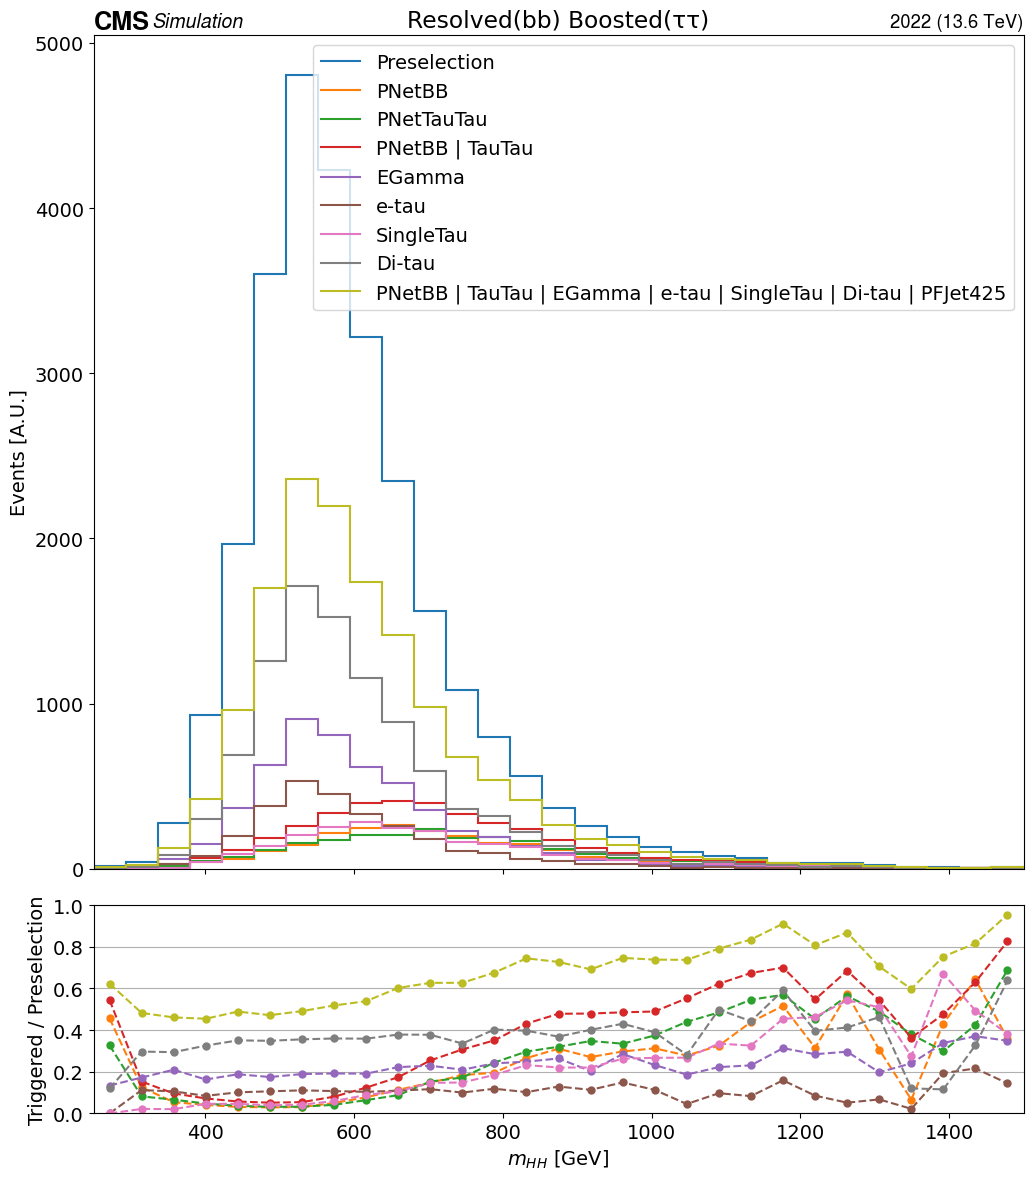

In [52]:
plt.rcParams.update({"font.size": 14})

plot_vars = [
    (mhh, "mhh", r"$m_{HH}$ [GeV]", np.linspace(250, 1500, 30)),
    # (hbbpt, "hbbpt", r"Hbb $p_{T}$ [GeV]", np.linspace(230, 500, 20)),
    # (httpt, "httpt", r"H$\tau\tau$ $p_{T}$ [GeV]", np.linspace(230, 500, 20)),
]

for cat, vals in triggers_dict.items():
    for kinvar, kinname, kinlabel, bins in plot_vars:
        (mask, label, triggers) = vals.values()

        fig, (ax, rax) = plt.subplots(
            2, 1, figsize=(12, 14), gridspec_kw=dict(height_ratios=[4, 1], hspace=0.07), sharex=True
        )

        hists = {"Preselection": np.histogram(kinvar[mask], bins=bins, weights=weights[mask])}
        ratios = {}

        hep.histplot(
            hists["Preselection"],
            yerr=False,
            label="Preselection",
            ax=ax,
        )

        colours = plt.cm.tab10.colors[1:]

        for key, c in zip(triggers.keys(), colours):
            # print(key)
            hists[key] = np.histogram(
                kinvar[mask & triggers[key]], bins=bins, weights=weights[mask & triggers[key]]
            )
            ratios[key] = hists[key][0] / hists["Preselection"][0]

            hep.histplot(
                hists[key],
                yerr=False,
                label=key,
                ax=ax,
                color=c,
            )

            hep.histplot(
                (ratios[key], bins),
                yerr=False,
                label=key,
                ax=rax,
                histtype="errorbar",
                color=c,
                # markersize=20,
                linestyle="--",
                # markeredgewidth=3,
                # fillstyle='none',
            )

        ax.set_ylabel("Events [A.U.]")
        ax.legend()
        ax.set_title(label)
        ax.set_xlim(bins[0], bins[-1])
        ax.set_ylim(0)

        # rax.legend()
        rax.grid(axis="y")
        rax.set_xlabel(kinlabel)
        rax.set_ylabel("Triggered / Preselection")

        ylims = [0.5, 1] if (cat.endswith("minus") and kinname != "mhh") else [0, 1]
        rax.set_ylim(ylims)

        hep.cms.label(ax=ax, data=False, year=2022, com="13.6")

        plt.savefig(plot_dir / f"{kinname}_{cat}.pdf", bbox_inches="tight")
        plt.show()

In [53]:
# We can also check for the trigger efficiency of this categories
# Make 2D histrogram plot for the Delta R vs the kin variables
# Change the threshold of the Delta R to be 1.0, 0.8 along with the Detra R one
# Chec fot he the trogger efficiencye and the reconstriction efficiency.
# what efficency can we reconstrucut (the semi resolved bbtautau). That is one of the them is ak8 bb fatjet and 2ak4 jets for the tautaus like ho many of the signal events pass that kind of selection 

# 
# Pt threshold of 100 and beyond

# Okay check that for the edge cases. 


'''
Raghav Kansal
  2:24 PM
notes from today's meeting:
nice plots from arghya looking at boosted vs resolved event fractions!
next steps:
2D histogram of dR vs. mHH, H pts
Check reco efficiencies for resolved vs boosted selections vs. mHH, H pts, where
resolved “pass” is finding 1 ak8 jet and 2 ak4 jets / 2 taus gen-matched to the two Higgses
boosted “pass” is 2 ak8 fatjets gen-matched to the two Higgses
'''


"\nRaghav Kansal\n  2:24 PM\nnotes from today's meeting:\nnice plots from arghya looking at boosted vs resolved event fractions!\nnext steps:\n2D histogram of dR vs. mHH, H pts\nCheck reco efficiencies for resolved vs boosted selections vs. mHH, H pts, where\nresolved “pass” is finding 1 ak8 jet and 2 ak4 jets / 2 taus gen-matched to the two Higgses\nboosted “pass” is 2 ak8 fatjets gen-matched to the two Higgses\n"

Median of ΔR(bb) = 2.0018774995194857
Median of ΔR(tautau) = 2.0098416135192814
Mean of ΔR(bb)   = 2.452830187773503
Mean of ΔR(tautau) = 2.45974536822731


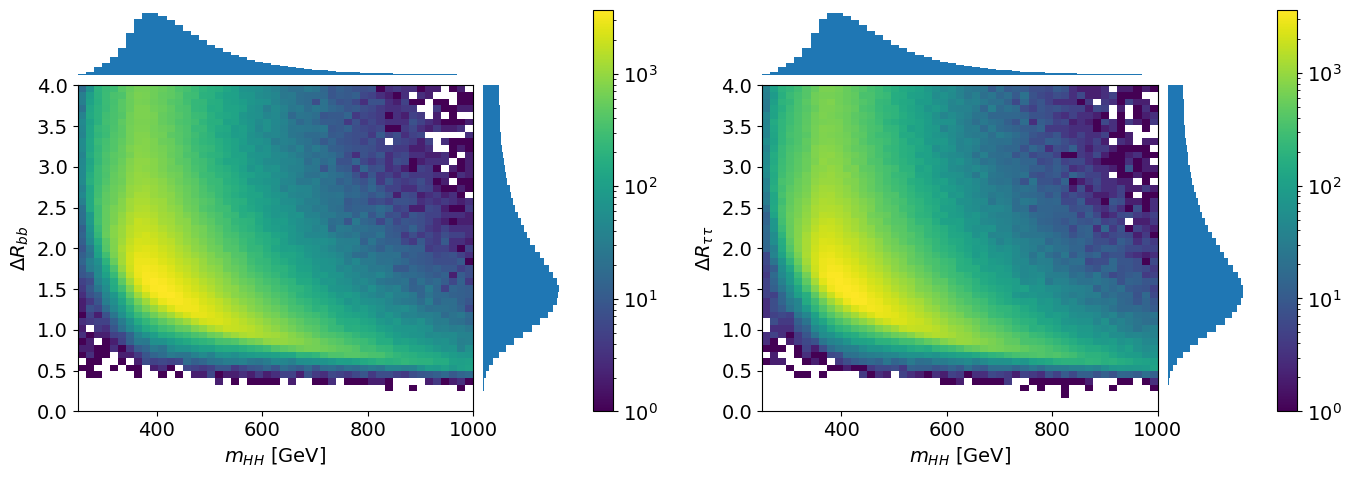

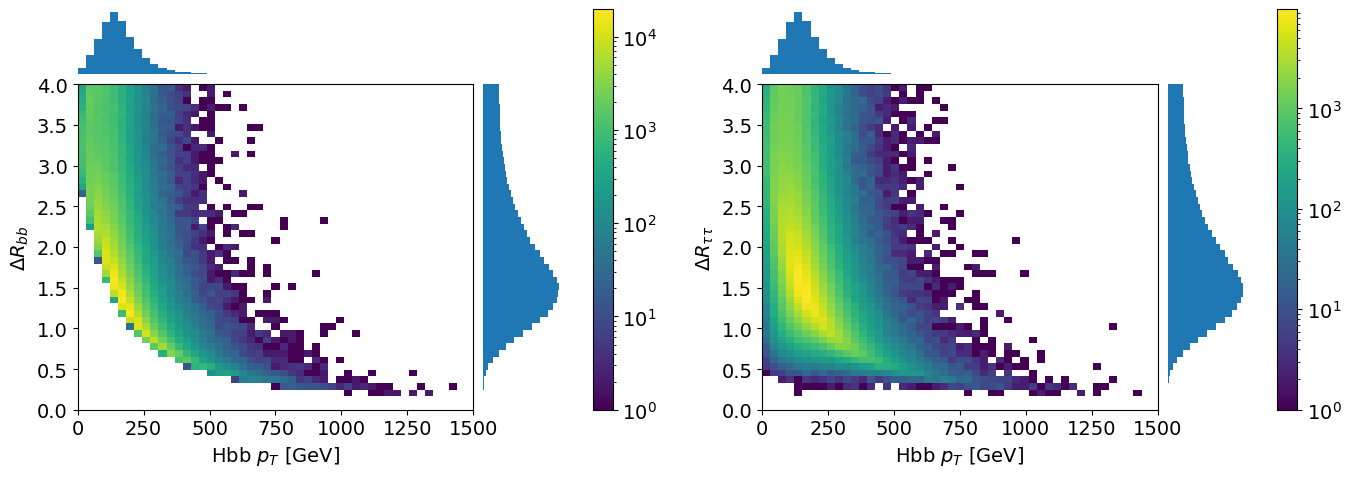

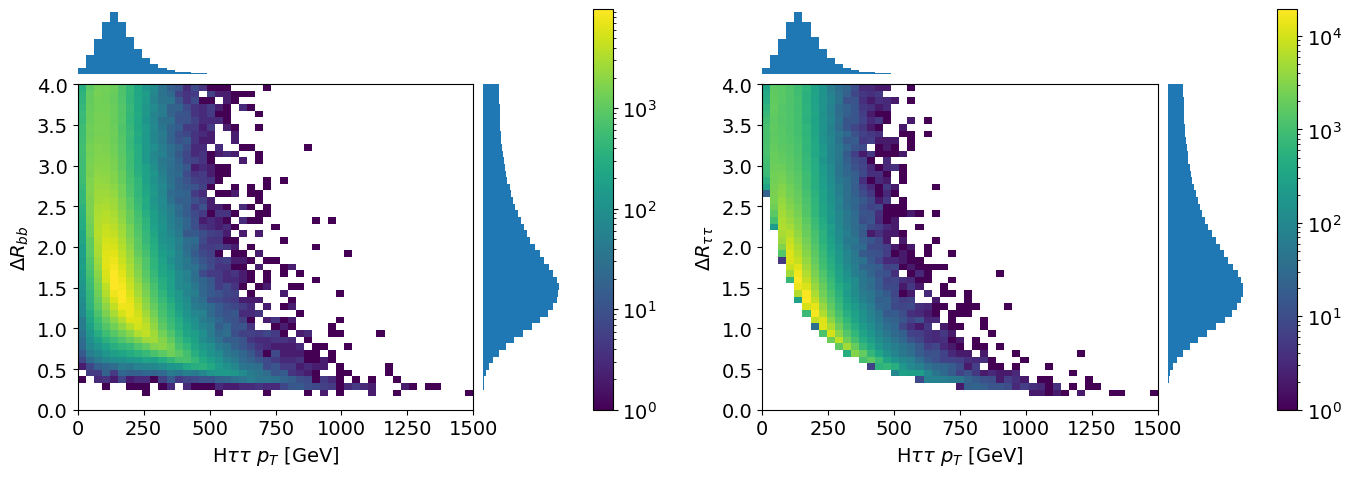

In [54]:

from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib import colors



plot_vars = [
    (mhh, "mhh", r"$m_{HH}$ [GeV]", np.linspace(250, 1000, 50)),
    (hbbpt, "hbbpt", r"Hbb $p_{T}$ [GeV]", np.linspace(0, 1500, 50)),
    (httpt, "httpt", r"H$\tau\tau$ $p_{T}$ [GeV]", np.linspace(0, 1500, 50)),
]

dr_bb_bins  = np.linspace(0, 4, 50)
dr_tau_bins = np.linspace(0, 4, 50)

print(f"Median of ΔR(bb) = {np.median(deltaR_bb)}")
print(f"Median of ΔR(tautau) = {np.median(deltaR_tau)}")
print(f"Mean of ΔR(bb)   = {np.mean(deltaR_bb)}")
print(f"Mean of ΔR(tautau) = {np.mean(deltaR_tau)}")

for var, var_name, xlabel, xbins in plot_vars:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # -- ΔR(bb) --
    divider1  = make_axes_locatable(ax1)
    ax1_top   = divider1.append_axes("top",   size="20%", pad=0.1, sharex=ax1)
    ax1_right = divider1.append_axes("right", size="20%", pad=0.1, sharey=ax1)

    h1 = ax1.hist2d(
        var,
        deltaR_bb,
        bins=[xbins, dr_bb_bins],
        norm=colors.LogNorm()
    )
    fig.colorbar(h1[3], ax=ax1)
    ax1.set_xlabel(xlabel)
    ax1.set_ylabel(r"$\Delta R_{bb}$")
    # ax1.set_title(f"{var_name} vs ΔR(bb)")

    ax1_top.hist(var, bins=xbins)
    ax1_top.axis("off")
    ax1_right.hist(deltaR_bb, bins=dr_bb_bins, orientation="horizontal")
    ax1_right.axis("off")

    # -- ΔR(ττ) --
    divider2  = make_axes_locatable(ax2)
    ax2_top   = divider2.append_axes("top",   size="20%", pad=0.1, sharex=ax2)
    ax2_right = divider2.append_axes("right", size="20%", pad=0.1, sharey=ax2)

    h2 = ax2.hist2d(
        var,
        deltaR_tau,
        bins=[xbins, dr_tau_bins],
        norm=colors.LogNorm()
        
    )
    fig.colorbar(h2[3], ax=ax2)
    ax2.set_xlabel(xlabel)
    ax2.set_ylabel(r"$\Delta R_{\tau\tau}$")
    # ax2.set_title(f"{var_name} vs ΔR(ττ)")

    ax2_top.hist(var, bins=xbins)
    ax2_top.axis("off")
    ax2_right.hist(deltaR_tau, bins=dr_tau_bins, orientation="horizontal")
    ax2_right.axis("off")

    
    plt.tight_layout()
    plt.show()



In [55]:
def delta_r(eta1, phi1, eta2, phi2):
    dphi = np.fmod(phi1 - phi2 + np.pi, 2*np.pi) - np.pi
    return np.sqrt((eta1 - eta2)**2 + dphi**2)

# Add other cuts:
# Ak8 Pt> 400 Gev
# Ak4 Pt> 30 Gev?
# One Ak8 to be bb
# Two di tau jets (Ak4)
def check_boosted_pass(event, dr_thr=0.8):
    """
    'Boosted' means we find 2 distinct AK8 jets, each matched
    within dr_thr to one of the two Gen Higgs.
    event is a dict that has e.g.:
      event["GenHiggsEta"] = [etaH0, etaH1]
      event["GenHiggsPhi"] = [phiH0, phiH1]
      event["ak8FatJetEta"] = [etaFJ0, etaFJ1, etaFJ2]
      etc.
    """
    higgs_eta = event["GenHiggsEta"]
    higgs_phi = event["GenHiggsPhi"]
    ak8_eta   = event["ak8FatJetEta"]
    ak8_phi   = event["ak8FatJetPhi"]
    
    # We will check if there is an ak8 that matches Higgs0
    # and a "different" ak8 that matches Higgs1.
    # We only have up to 3 ak8 jets (indices 0, 12).
    matched_higgs = [False, False]  # H0 matched? H1 matched?
    used_ak8 = set()                # which ak8 indices are used
    
    for iH in [0,1]:
        for iFJ in range(len(ak8_eta)):
            dR_val = delta_r(higgs_eta[iH], higgs_phi[iH],
                             ak8_eta[iFJ],   ak8_phi[iFJ])
            if dR_val < dr_thr and (iFJ not in used_ak8):
                matched_higgs[iH] = True
                used_ak8.add(iFJ)
                break

    return all(matched_higgs)

def check_resolved_pass(event, dr_thr_ak4=0.4, dr_thr_ak8=0.8):
    """
    'Resolved' pass = we can match one Higgs to 2 distinct AK4 jets,
    and the other Higgs to 1 AK8 jet. 
    (Because you only have AK4/AK8 in your columns, no actual Tau reco.)
    """
    # Define GenHiggs0 as H->bb, GenHiggs1 as H->ττ, or vice versa.
    
    def can_match_two_ak4_to_higgs(hidx):
        # Look to match 2 distinct AK4 jets to H(hidx).
        # TODO: Iclude the child of higgs too
        h_eta = event["GenHiggsEta"][hidx]
        h_phi = event["GenHiggsPhi"][hidx]
        ak4_eta = event["ak4JetEta"]
        ak4_phi = event["ak4JetPhi"]
        possible_jets = []
        for iJ in range(len(ak4_eta)):
            dR_val = delta_r(h_eta, h_phi, ak4_eta[iJ], ak4_phi[iJ])
            if dR_val < dr_thr_ak4:
                possible_jets.append(iJ)
        # We pass if at least 2 distinct jets match
        return (len(possible_jets) >= 2)

    def can_match_one_ak8_to_higgs(hidx):
        # One AK8 within dr_thr_ak8
        h_eta = event["GenHiggsEta"][hidx]
        h_phi = event["GenHiggsPhi"][hidx]
        ak8_eta = event["ak8FatJetEta"]
        ak8_phi = event["ak8FatJetPhi"]
        for iFJ in range(len(ak8_eta)):
            dR_val = delta_r(h_eta, h_phi, ak8_eta[iFJ], ak8_phi[iFJ])
            if dR_val < dr_thr_ak8:
                return True
        return False

    # Two possible ways to do "resolved pass":
    #   (H0 has 2 AK4 jets, H1 has 1 AK8) OR
    #   (H1 has 2 AK4 jets, H0 has 1 AK8)
    caseA = can_match_two_ak4_to_higgs(0) and can_match_one_ak8_to_higgs(1)
    caseB = can_match_two_ak4_to_higgs(1) and can_match_one_ak8_to_higgs(0)
    return caseA or caseB


n_rows = len(df) 
boosted_results = []
resolved_results = []

for i in range(n_rows):
    event = {
        "GenHiggsEta": [
            df[('GenHiggsEta',0)][i],
            df[('GenHiggsEta',1)][i],
        ],
        "GenHiggsPhi": [
            df[('GenHiggsPhi',0)][i],
            df[('GenHiggsPhi',1)][i],
        ],
        "ak8FatJetEta": [
            df[('ak8FatJetEta',j)][i] 
            for j in [0,1,2] if not np.isnan(df[('ak8FatJetEta',j)][i])
        ],
        "ak8FatJetPhi": [
            df[('ak8FatJetPhi',j)][i] 
            for j in [0,1,2] if not np.isnan(df[('ak8FatJetPhi',j)][i])
        ],
        "ak4JetEta": [
            df[('ak4JetEta',j)][i] 
            for j in [0,1,2,3] if not np.isnan(df[('ak4JetEta',j)][i])
        ],
        "ak4JetPhi": [
            df[('ak4JetPhi',j)][i] 
            for j in [0,1,2,3] if not np.isnan(df[('ak4JetPhi',j)][i])
        ],
    }
    
    boosted_pass  = check_boosted_pass(event, dr_thr=0.8)
    resolved_pass = check_resolved_pass(event, dr_thr_ak4=0.4,
                                        dr_thr_ak8=0.8)
    boosted_results.append(boosted_pass)
    resolved_results.append(resolved_pass)

# Convert results to numpy arrays
boosted_results  = np.array(boosted_results, dtype=bool)
resolved_results = np.array(resolved_results, dtype=bool)



KeyboardInterrupt: 

In [ ]:
# Try opening NanoAOD file with uproot

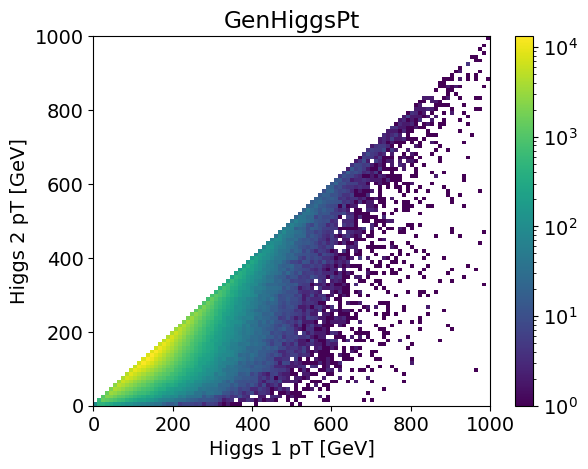

In [ ]:
pt1 = df[('GenHiggsPt', 0)].to_numpy()
pt2 = df[('GenHiggsPt', 1)].to_numpy()

H1 = np.maximum(pt1, pt2)
H2 = np.minimum(pt1, pt2)

plt.hist2d(H1, H2, bins=np.linspace(0, 1000, 100), norm=colors.LogNorm())
plt.xlabel("Higgs 1 pT [GeV]")
plt.ylabel("Higgs 2 pT [GeV]")
plt.colorbar()
plt.title("GenHiggsPt")

plt.show()

-99999.0


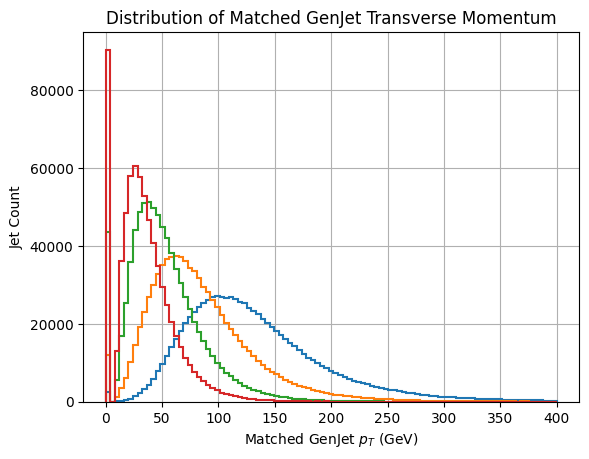

In [ ]:
var_name = 'ak4JetMatchedGenJetPt'

print(min(df[(var_name, 0)]))

bins = np.linspace(0, 400, 100)

plt.hist(df[(var_name, 0)], bins=bins, histtype='step', linewidth=1.5, label="Jet 0")
plt.hist(df[(var_name, 1)], bins=bins, histtype='step', linewidth=1.5, label="Jet 1")
plt.hist(df[(var_name, 2)], bins=bins, histtype='step', linewidth=1.5, label="Jet 2")
plt.hist(df[(var_name, 3)], bins=bins, histtype='step', linewidth=1.5, label="Jet 3")

plt.xlabel("Matched GenJet $p_T$ (GeV)")
plt.ylabel("Jet Count")
plt.title("Distribution of Matched GenJet Transverse Momentum")

plt.grid(True)
plt.show()

-99999.0


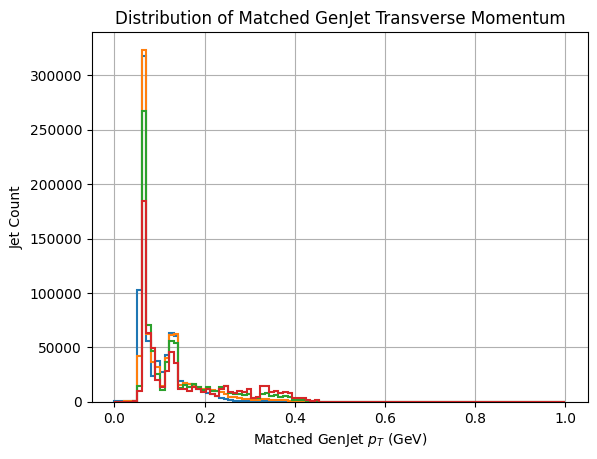

In [ ]:
var_name = 'ak4JetrawFactor'

print(min(df[(var_name, 0)]))

bins = np.linspace(0, 1, 100)

plt.hist(df[(var_name, 0)], bins=bins, histtype='step', linewidth=1.5, label="Jet 0")
plt.hist(df[(var_name, 1)], bins=bins, histtype='step', linewidth=1.5, label="Jet 1")
plt.hist(df[(var_name, 2)], bins=bins, histtype='step', linewidth=1.5, label="Jet 2")
plt.hist(df[(var_name, 3)], bins=bins, histtype='step', linewidth=1.5, label="Jet 3")

plt.xlabel("Matched GenJet $p_T$ (GeV)")
plt.ylabel("Jet Count")
plt.title("Distribution of Matched GenJet Transverse Momentum")

plt.grid(True)
plt.show()

In [ ]:
Higgs_Pt_threshold = 250  # GeV
BbbBtautau = 0
BbbRtautau = 0
RbbBtautau = 0
RbbRtautau = 0

deltaR_bb = np.sqrt((df[('GenbbEta', 0)] - df[('GenbbEta', 1)])**2 +
                     (df[('GenbbPhi', 0)] - df[('GenbbPhi', 1)])**2)

deltaR_tau = np.sqrt((df[('GenTauEta', 0)] - df[('GenTauEta', 1)])**2 +
                      (df[('GenTauPhi', 0)] - df[('GenTauPhi', 1)])**2)

for i in range(nEvents):
    H1_Pt = df[('GenHiggsPt', 0)][i]
    H2_Pt = df[('GenHiggsPt', 1)][i]
    H1_children = df[('GenHiggsChildren', 0)][i]
    H2_children = df[('GenHiggsChildren', 1)][i]
    
    if (H1_Pt >= Higgs_Pt_threshold) or (H2_Pt >= Higgs_Pt_threshold):
        boosted_H = H1_Pt >= Higgs_Pt_threshold
        resolved_H = H2_Pt < Higgs_Pt_threshold
        
        if boosted_H and H1_children == 5:
            if deltaR_bb[i] < deltaR_threshold:
                if resolved_H and deltaR_tau[i] >= deltaR_threshold:
                    BbbRtautau += 1
                elif not resolved_H and deltaR_tau[i] < deltaR_threshold:
                    BbbBtautau += 1
            else:
                if resolved_H and deltaR_tau[i] >= deltaR_threshold:
                    RbbRtautau += 1
                elif not resolved_H and deltaR_tau[i] < deltaR_threshold:
                    RbbBtautau += 1
        
        elif resolved_H and H2_children == 5:
            if deltaR_bb[i] < deltaR_threshold:
                if boosted_H and deltaR_tau[i] < deltaR_threshold:
                    BbbBtautau += 1
                elif not boosted_H and deltaR_tau[i] >= deltaR_threshold:
                    BbbRtautau += 1
            else:
                if boosted_H and deltaR_tau[i] < deltaR_threshold:
                    RbbBtautau += 1
                elif not boosted_H and deltaR_tau[i] >= deltaR_threshold:
                    RbbRtautau += 1

print("BbbBtautau: ", BbbBtautau)
print("BbbRtautau: ", BbbRtautau)
print("RbbBtautau: ", RbbBtautau)
print("RbbRtautau: ", RbbRtautau)

KeyboardInterrupt: 

In [ ]:
print("BbbBtautau: ", BbbBtautau)
print("BbbRtautau: ", BbbRtautau)
print("RbbBtautau: ", RbbBtautau)
print("RbbRtautau: ", RbbRtautau)

BbbBtautau:  19589
BbbRtautau:  8902
RbbBtautau:  15711
RbbRtautau:  4708


In [ ]:
H1_Pt = df[('GenHiggsPt', 0)].to_numpy()
H2_Pt = df[('GenHiggsPt', 1)].to_numpy()
H1_children = df[('GenHiggsChildren', 0)].to_numpy()
H2_children = df[('GenHiggsChildren', 1)].to_numpy()
deltaR_bb_arr = deltaR_bb.to_numpy()
deltaR_tau_arr = deltaR_tau.to_numpy()


In [ ]:

# Compute conditions in a vectorized manner
boosted_H = H1_Pt >= Higgs_Pt_threshold
resolved_H = H2_Pt < Higgs_Pt_threshold

# Masks for the conditions
boosted_H1_with_5 = (boosted_H & (H1_children == 5))
resolved_H2_with_5 = (resolved_H & (H2_children == 5))
bb_close = deltaR_bb_arr < deltaR_threshold
tau_far = deltaR_tau_arr >= deltaR_threshold
tau_close = deltaR_tau_arr < deltaR_threshold

# Compute the category counts using NumPy sum (faster than loops)
BbbRtautau = np.sum(boosted_H1_with_5 & bb_close & resolved_H & tau_far)
BbbBtautau = np.sum(boosted_H1_with_5 & bb_close & ~resolved_H & tau_close)
RbbRtautau = np.sum(boosted_H1_with_5 & ~bb_close & resolved_H & tau_far)
RbbBtautau = np.sum(boosted_H1_with_5 & ~bb_close & ~resolved_H & tau_close)


print("BbbBtautau: ", BbbBtautau)
print("BbbRtautau: ", BbbRtautau)
print("RbbBtautau: ", RbbBtautau)
print("RbbRtautau: ", RbbRtautau)

BbbBtautau:  16697
BbbRtautau:  8902
RbbBtautau:  6774
RbbRtautau:  4708


In [ ]:
boosted_H1 = H1_Pt >= Higgs_Pt_threshold
boosted_H2 = H2_Pt >= Higgs_Pt_threshold
resolved_H1 = ~boosted_H1  
resolved_H2 = ~boosted_H2

H1_has_bb = H1_children == 5
H2_has_bb = H2_children == 5
H1_has_TauTau = H1_children == 15
H2_has_TauTau = H2_children == 15

boosted_bb = deltaR_bb < deltaR_threshold
resolved_bb = deltaR_bb >= deltaR_threshold

boosted_tau = deltaR_tau < deltaR_threshold
resolved_tau = deltaR_tau >= deltaR_threshold


BbbBtautau = np.sum(
    (boosted_H1 & H1_has_bb) &
    (boosted_H2 & H2_has_TauTau) &
    (boosted_bb & boosted_tau)
)

BbbRtautau = np.sum(
    (boosted_H1 & H1_has_bb) &
    (resolved_H2 & H2_has_TauTau) &
    (boosted_bb & resolved_tau)
)

RbbBtautau = np.sum(
    (resolved_H1 & H1_has_bb) &
    (boosted_H2 & H2_has_TauTau) &
    (resolved_bb & boosted_tau)
)

RbbRtautau = np.sum(
    (resolved_H1 & H1_has_bb) &
    (resolved_H2 & H2_has_TauTau) &
    (resolved_bb & resolved_tau)
)

# Now consider the opposite where H1 is tautau and H2 is bb


BbbBtautau += np.sum(
    (boosted_H1 & H1_has_TauTau) &
    (boosted_H2 & H2_has_bb) &
    (boosted_tau & boosted_bb)
)

BbbRtautau += np.sum(
    (boosted_H1 & H1_has_TauTau) &
    (resolved_H2 & H2_has_bb) &
    (boosted_tau & resolved_bb)
)

RbbBtautau += np.sum(
    (resolved_H1 & H1_has_TauTau) &
    (boosted_H2 & H2_has_bb) &
    (resolved_tau & boosted_bb)
)

RbbRtautau += np.sum(
    (resolved_H1 & H1_has_TauTau) &
    (resolved_H2 & H2_has_bb) &
    (resolved_tau & resolved_bb)
)


# Print the results
print("BbbBtautau: ", BbbBtautau)
print("BbbRtautau: ", BbbRtautau)
print("RbbBtautau: ", RbbBtautau)
print("RbbRtautau: ", RbbRtautau)



BbbBtautau:  33491
BbbRtautau:  17839
RbbBtautau:  17860
RbbRtautau:  634908


In [ ]:
BbbBtautau = np.sum(
    (boosted_H1 & boosted_H2) &
    (boosted_tau & boosted_bb)
)

BbbRtautau = np.sum(
    (boosted_H1 & resolved_H2) &
    (boosted_tau & resolved_bb)
)

RbbBtautau = np.sum(
    (resolved_H1 & boosted_H2) &
    (resolved_tau & boosted_bb)
)

RbbRtautau = np.sum(
    (resolved_H1 & resolved_H2) &
    (resolved_tau & resolved_bb)
)


# Print the results
print("BbbBtautau: ", BbbBtautau)
print("BbbRtautau: ", BbbRtautau)
print("RbbBtautau: ", RbbBtautau)
print("RbbRtautau: ", RbbRtautau)

BbbBtautau:  33491
BbbRtautau:  10604
RbbBtautau:  10713
RbbRtautau:  634908
